# Predicción de Suscripción a Depósito a Plazo Fijo
### Análisis de Clasificación — Campañas de Marketing Bancario (Portugal, 2008–2013)

---

> **Fuente:** Moro, S., Cortez, P. & Rita, P. (2014). *A Data-Driven Approach to Predict the Success of Bank Telemarketing.* Decision Support Systems.  
> **Repositorio:** UCI Machine Learning Repository — Bank Marketing Dataset  
> **Dimensión original:** 41,188 registros × 21 variables

---

## 1. Contexto y Planteamiento del Problema

### El reto de las campañas de captación bancaria

Los **depósitos a plazo fijo** son uno de los instrumentos de captación más importantes para la banca comercial: el cliente inmoviliza su capital por un periodo definido a cambio de una tasa de interés garantizada, y el banco utiliza esos recursos para financiar su cartera de crédito. Sin embargo, la venta telefónica de estos productos es costosa: cada llamada consume tiempo de un agente especializado, y la mayoría termina sin conversión.

Este estudio trabaja con datos de una institución bancaria portuguesa que realizó campañas de telemarketing entre 2008 y 2013, periodo marcado por la crisis financiera del euro y la recesión económica en Portugal. Al final de ese proceso, **solo el 11.3% de los clientes contactados terminó suscribiendo un depósito a plazo**.

### ¿Qué queremos predecir y por qué importa?

La pregunta central es: **¿suscribirá este cliente un depósito a plazo fijo?** La variable de salida (`y`) es binaria: *yes* o *no*.

Un modelo de clasificación que estime la probabilidad de conversión de cada cliente permitiría al banco:

- **Priorizar la agenda de sus agentes**: contactar primero a los clientes con mayor probabilidad de suscribir, en lugar de llamar en orden arbitrario.
- **Reducir el costo operativo**: evitar invertir llamadas en perfiles con probabilidad muy baja de conversión.
- **Entender el fenómeno**: identificar qué características del cliente y del contexto económico son determinantes para la decisión.

El enfoque de clasificación supervisada es adecuado porque la salida es categórica (dos clases), tenemos datos históricos etiquetados, y buscamos generalizar el aprendizaje a clientes nuevos.

### Sobre las métricas: por qué no usaremos solo exactitud (*accuracy*)

Antes de iniciar el análisis, es importante establecer cuáles métricas usaremos para evaluar y comparar los modelos, y por qué.

Con un desbalance de ~8:1 (no:sí), un modelo que prediga siempre "no" tendría una **exactitud del 88.7% sin aprender absolutamente nada**. La exactitud es por tanto una métrica engañosa en este problema.

Usaremos en cambio el **AUC-ROC** (Área Bajo la Curva ROC) como métrica principal:

- La **curva ROC** grafica la Tasa de Verdaderos Positivos (Recall) contra la Tasa de Falsos Positivos para todos los posibles umbrales de clasificación.
- El **AUC** es el área bajo esa curva, y se interpreta como: *si tomamos aleatoriamente un cliente que sí suscribió y uno que no, ¿con qué frecuencia el modelo asigna mayor probabilidad al que sí suscribió?* Un AUC de 0.5 equivale a adivinar al azar; un AUC de 1.0 sería clasificación perfecta.
- La ventaja del AUC es que **no depende de ningún umbral de clasificación específico** y es robusta al desbalance de clases.

Complementariamente, reportaremos el **F1-Score**, que balancea precisión y recall, útil cuando los costos de falsos positivos y falsos negativos son asimétricos.

**Sobre el umbral de clasificación:** por defecto, los modelos clasifican como positivo cuando la probabilidad predicha supera 0.5. Sin embargo, este umbral puede ajustarse según las prioridades del negocio: bajarlo captura más clientes potenciales (mayor recall) pero genera más llamadas innecesarias (más falsos positivos); subirlo hace lo contrario. Exploraremos este trade-off en la sección de evaluación final.

## 2. Configuración del Entorno

A continuación se cargan todas las bibliotecas necesarias para el análisis. Las principales son: `pandas` y `numpy` para la manipulación de datos, `matplotlib` y `seaborn` para visualización, `statsmodels` para inferencia estadística (p-values, odds ratios), `scipy` para pruebas de normalidad, `sklearn` para el preprocesamiento y los modelos de clasificación, y `tensorflow/keras` para la red neuronal.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from scipy import stats

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV, StratifiedShuffleSplit
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    accuracy_score, ConfusionMatrixDisplay, precision_recall_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

print('Entorno cargado correctamente ✓')

Entorno cargado correctamente ✓


## 3. Carga y Exploración Inicial de Datos

### 3.1 Carga del dataset y primeras observaciones

In [2]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
print(f'Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(5)

Dimensiones: 41,188 filas × 21 columnas


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


La tabla anterior muestra los primeros 5 registros del dataset. Cada fila es un **contacto individual** a un cliente durante la campaña de telemarketing. Las columnas recopilan información de tres tipos:

- **Perfil del cliente**: `age` (edad), `job` (ocupación), `marital` (estado civil), `education` (nivel educativo), `default`/`housing`/`loan` (historial crediticio e hipotecario).
- **Contacto y campaña**: `contact` (tipo de teléfono), `month` y `day_of_week` (cuándo se llamó), `duration` (duración de la llamada en segundos), `campaign` (cuántas veces fue contactado en esta campaña).
- **Contexto económico**: `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` — indicadores macroeconómicos de Portugal en el momento del contacto.

La última columna `y` es nuestra variable objetivo: `no` significa que el cliente no suscribió un depósito a plazo fijo, `yes` que sí lo hizo. A simple vista, todos los primeros 5 registros son `no` — un primer indicio de que los casos positivos son relativamente poco frecuentes en el dataset.

### 3.2 Tipos computacional vs. tipo estadístico de cada variable

Antes de cualquier análisis, es fundamental distinguir entre el **tipo computacional** (cómo Python almacena la variable: `int`, `float`, `object`) y el **tipo estadístico** (qué representa realmente esa variable: cuantitativa continua, cuantitativa discreta, o categórica nominal/ordinal).

Este paso es crítico porque Python puede codificar categorías como números — por ejemplo, un nivel educativo representado con valores [0, 1, 2, 3, 4] — y si lo tratamos como variable numérica continua, los modelos le darán un significado de magnitud que no corresponde a la realidad.

In [3]:
type_analysis = {
    'Variable':       ['age','duration','campaign','pdays','previous',
                       'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed',
                       'job','marital','education','default','housing','loan',
                       'contact','month','day_of_week','poutcome','y'],
    'Tipo computacional': ['int64','int64','int64','int64','int64',
                           'float64','float64','float64','float64','float64',
                           'object','object','object','object','object','object',
                           'object','object','object','object','object'],
    'Tipo estadístico': [
        'Cuant. discreta (años)',
        'Cuant. continua (segundos)',
        'Cuant. discreta (conteo)',
        'Especial: 999 = nunca contactado; resto discreta',
        'Cuant. discreta (0–7) — puede tratarse como ordinal',
        'Cuasi-categórica: solo 10 valores únicos (trimestral)',
        'Cuasi-categórica: 26 valores únicos (mensual)',
        'Cuasi-categórica: 26 valores únicos (mensual)',
        'Cuant. continua (tasa de mercado)',
        'Cuasi-categórica: solo 11 valores únicos (trimestral)',
        'Categórica nominal (12 clases)',
        'Categórica nominal (4 clases)',
        'Categórica ordinal (8 niveles)',
        'Categórica nominal (3 clases)',
        'Categórica nominal (3 clases)',
        'Categórica nominal (3 clases)',
        'Categórica nominal (2 clases)',
        'Categórica cíclica (10 meses)',
        'Categórica cíclica (5 días)',
        'Categórica nominal (3 clases)',
        'OBJETIVO: binaria (yes/no)'
    ],
    'Tratamiento previsto': [
        'Usar como numérica',
        'Usar como numérica',
        'Usar como numérica',
        'Crear flag binaria contacted_before; recodificar 999→0',
        'Usar como numérica (bajo rango, no recodificar)',
        'Usar como numérica (reportada por Eurostat)',
        'Usar como numérica (reportada por Eurostat)',
        'Usar como numérica (reportada por Eurostat)',
        'Usar como numérica',
        'Usar como numérica (reportada por Eurostat)',
        'One-Hot Encoding (drop_first)',
        'One-Hot Encoding (drop_first)',
        'One-Hot Encoding (drop_first)',
        'One-Hot Encoding (drop_first)',
        'One-Hot Encoding (drop_first)',
        'One-Hot Encoding (drop_first)',
        'One-Hot Encoding (drop_first)',
        'One-Hot Encoding (drop_first)',
        'One-Hot Encoding (drop_first)',
        'One-Hot Encoding (drop_first)',
        'Codificar: yes=1, no=0'
    ]
}

pd.DataFrame(type_analysis)

,Variable,Tipo computacional,Tipo estadístico,Tratamiento previsto
0,age,int64,Cuant. discreta (años),Usar como numérica
1,duration,int64,Cuant. continua (segundos),Usar como numérica
2,campaign,int64,Cuant. discreta (conteo),Usar como numérica
3,pdays,int64,Especial: 999 = nunca contactado; resto discreta,Crear flag binaria contacted_before; recodific...
4,previous,int64,Cuant. discreta (0–7) — puede tratarse como or...,"Usar como numérica (bajo rango, no recodificar)"
5,emp.var.rate,float64,Cuasi-categórica: solo 10 valores únicos (trim...,Usar como numérica (reportada por Eurostat)
6,cons.price.idx,float64,Cuasi-categórica: 26 valores únicos (mensual),Usar como numérica (reportada por Eurostat)
7,cons.conf.idx,float64,Cuasi-categórica: 26 valores únicos (mensual),Usar como numérica (reportada por Eurostat)
8,euribor3m,float64,Cuant. continua (tasa de mercado),Usar como numérica
9,nr.employed,float64,Cuasi-categórica: solo 11 valores únicos (trim...,Usar como numérica (reportada por Eurostat)


**Observaciones importantes sobre el tipo estadístico:**

- **`emp.var.rate`** (10 valores únicos), **`nr.employed`** (11 valores únicos), **`cons.price.idx`** y **`cons.conf.idx`** (26 valores únicos cada una) son estadísticamente **cuasi-categóricas**: son indicadores macroeconómicos reportados a frecuencia trimestral o mensual, por lo que adoptan un número muy reducido de valores posibles. Sin embargo, dado que son publicados por Eurostat y representan magnitudes con sentido de orden y escala (no son etiquetas arbitrarias), las trataremos como numéricas continuas en el modelado.

- **`previous`** (valores 0 a 7) es discreta con muy pocos valores posibles — podría recodificarse como ordinal, pero dado que el modelo capturará su efecto al usarla como numérica y su rango es pequeño, se mantiene así.

- **`pdays`** merece atención especial: el valor 999 no es un número real sino una bandera que indica "nunca contactado antes". Si la usáramos directamente como numérica, el modelo interpretaría que una distancia de 999 días tiene una relación lineal con la suscripción, lo cual es incorrecto. La solución es **crear una variable binaria** que capture si el cliente fue contactado antes, y tratar `pdays` solo para los que sí lo fueron.

- Las variables categóricas de texto (`job`, `marital`, `education`, etc.) se codificarán con **One-Hot Encoding** — esto convierte cada categoría en una columna binaria, permitiendo que los modelos lineales trabajen con ellas sin imponer un orden artificial.

### 3.3 Balance de clases

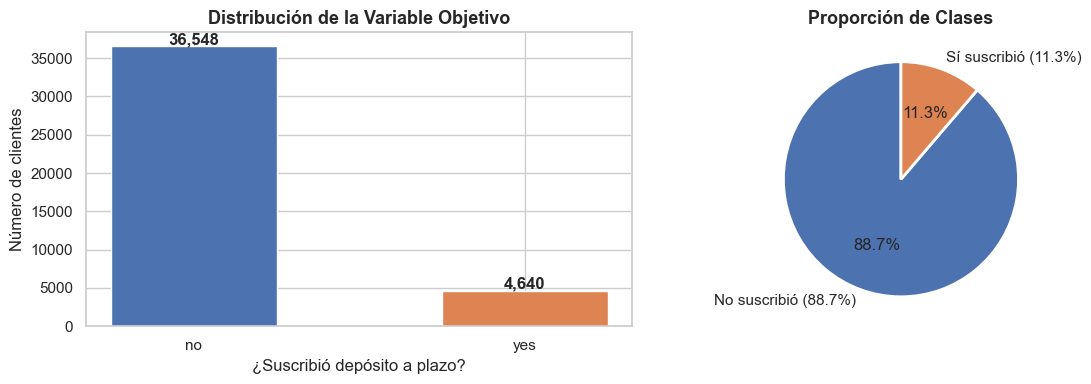

Clientes que NO suscribieron: 36,548 (88.7%)
Clientes que SÍ suscribieron: 4,640 (11.3%)
Ratio de desbalance: 7.9:1  (no:sí)


In [4]:
class_counts = df['y'].value_counts()
class_pct    = df['y'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#4C72B0', '#DD8452']

bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Distribución de la Variable Objetivo', fontweight='bold')
axes[0].set_ylabel('Número de clientes')
axes[0].set_xlabel('¿Suscribió depósito a plazo?')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 300,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=12)

axes[1].pie(class_counts.values,
            labels=[f'No suscribió ({class_pct["no"]:.1f}%)',
                    f'Sí suscribió ({class_pct["yes"]:.1f}%)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Clases', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Clientes que NO suscribieron: {class_counts["no"]:,} ({class_pct["no"]:.1f}%)')
print(f'Clientes que SÍ suscribieron: {class_counts["yes"]:,} ({class_pct["yes"]:.1f}%)')
print(f'Ratio de desbalance: {class_counts["no"]/class_counts["yes"]:.1f}:1  (no:sí)')

**Interpretación:** El dataset presenta un desbalance severo de aproximadamente **8 a 1** entre la clase negativa y la positiva. Esto tiene consecuencias directas en cómo debemos evaluar y entrenar los modelos. Como se mencionó en la introducción, un clasificador trivial que siempre prediga "no suscribe" tendría una exactitud del 88.7% sin aprender nada. Por esta razón, todas las comparaciones de modelos se realizarán con **AUC-ROC**, y donde los algoritmos lo permitan, se activará el parámetro `class_weight='balanced'` para que el modelo penalice más los errores en la clase minoritaria (sí suscribió) durante el entrenamiento.

### 3.4 Estadística descriptiva de variables numéricas

El siguiente paso es revisar los estadísticos básicos de las variables numéricas. Más allá de la media y la desviación estándar, los valores **mínimo y máximo** son especialmente útiles para detectar si una variable que Python considera numérica es en realidad categórica estadísticamente — por ejemplo, si el mínimo es 0 y el máximo es 4 con muy pocos valores únicos intermedios.

In [5]:
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
            'euribor3m', 'nr.employed']

desc = df[num_cols].describe().round(2)

# Añadimos conteo de únicos para facilitar la identificación de cuasi-categóricas
desc.loc['unique'] = [df[c].nunique() for c in num_cols]
desc

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10
unique,78.00,1544.00,42.00,27.00,8.00,10.00,26.00,26.00,316.00,11.00


**Interpretación de la tabla:**

- **`age`**: rango de 17 a 98 años con 78 valores únicos. Variable cuantitativa discreta real — cada año es un valor posible. Media de 40 años.

- **`duration`**: rango de 0 a 4,918 segundos. El mínimo de 0 es una señal de alerta — una llamada de duración cero no tiene sentido operativo. Se tratará en la sección de limpieza. El máximo de 4,918 segundos (≈82 minutos) es inusual pero posible.

- **`campaign`**: entre 1 y 56 contactos. La media es solo 2.6, pero el máximo de 56 sugiere casos extremos de insistencia comercial.

- **`pdays`**: mínimo 0, máximo **999**. El valor 999 claramente no representa días — como se documentó en la tabla de tipos, es una bandera que indica "este cliente nunca fue contactado en campañas anteriores". Se recodificará.

- **`previous`**: solo **8 valores únicos** (0 a 7). Aunque computacionalmente es `int64`, estadísticamente es discreta con muy pocos niveles.

- **`emp.var.rate`**: solo **10 valores únicos**. Indicador macroeconómico trimestral — la granularidad es baja por diseño.

- **`nr.employed`**: solo **11 valores únicos**. Indicador trimestral del mercado laboral — similar caso.

- **`cons.price.idx`** y **`cons.conf.idx`**: 26 valores únicos cada una. Indicadores mensuales.

- **`euribor3m`**: 316 valores únicos. Es la única variable macroeconómica que se comporta como verdaderamente continua (tasa de mercado diaria).

> **⚠️ NOTA METODOLÓGICA: El caso especial de `duration`**
>
> Durante esta fase exploratoria analizaremos la variable `duration` (duración de la llamada) porque aporta un gran valor analítico para entender el comportamiento histórico. Sin embargo, **esta variable será descartada estrictamente antes de la fase de modelado**.
>
> *Justificación de negocio y técnica:* En un entorno de producción real, el modelo debe priorizar a los clientes *antes* de que el agente marque el número. No podemos conocer la duración de una llamada que aún no ocurre. Incluir esta variable introduciría una **fuga de datos (Data Leakage)** severa, ya que las llamadas largas son a menudo la consecuencia directa de que el cliente está aceptando el depósito. Mantenerla inflaría artificialmente las métricas del modelo, creando un sistema inútil para la operación real.

### 3.5 Distribuciones por clase y análisis de normalidad

Visualizamos la distribución de cada variable numérica separada por clase objetivo, lo que nos permite ver si hay diferencias entre quienes suscribieron y quienes no, y si las distribuciones se aproximan a la normalidad.

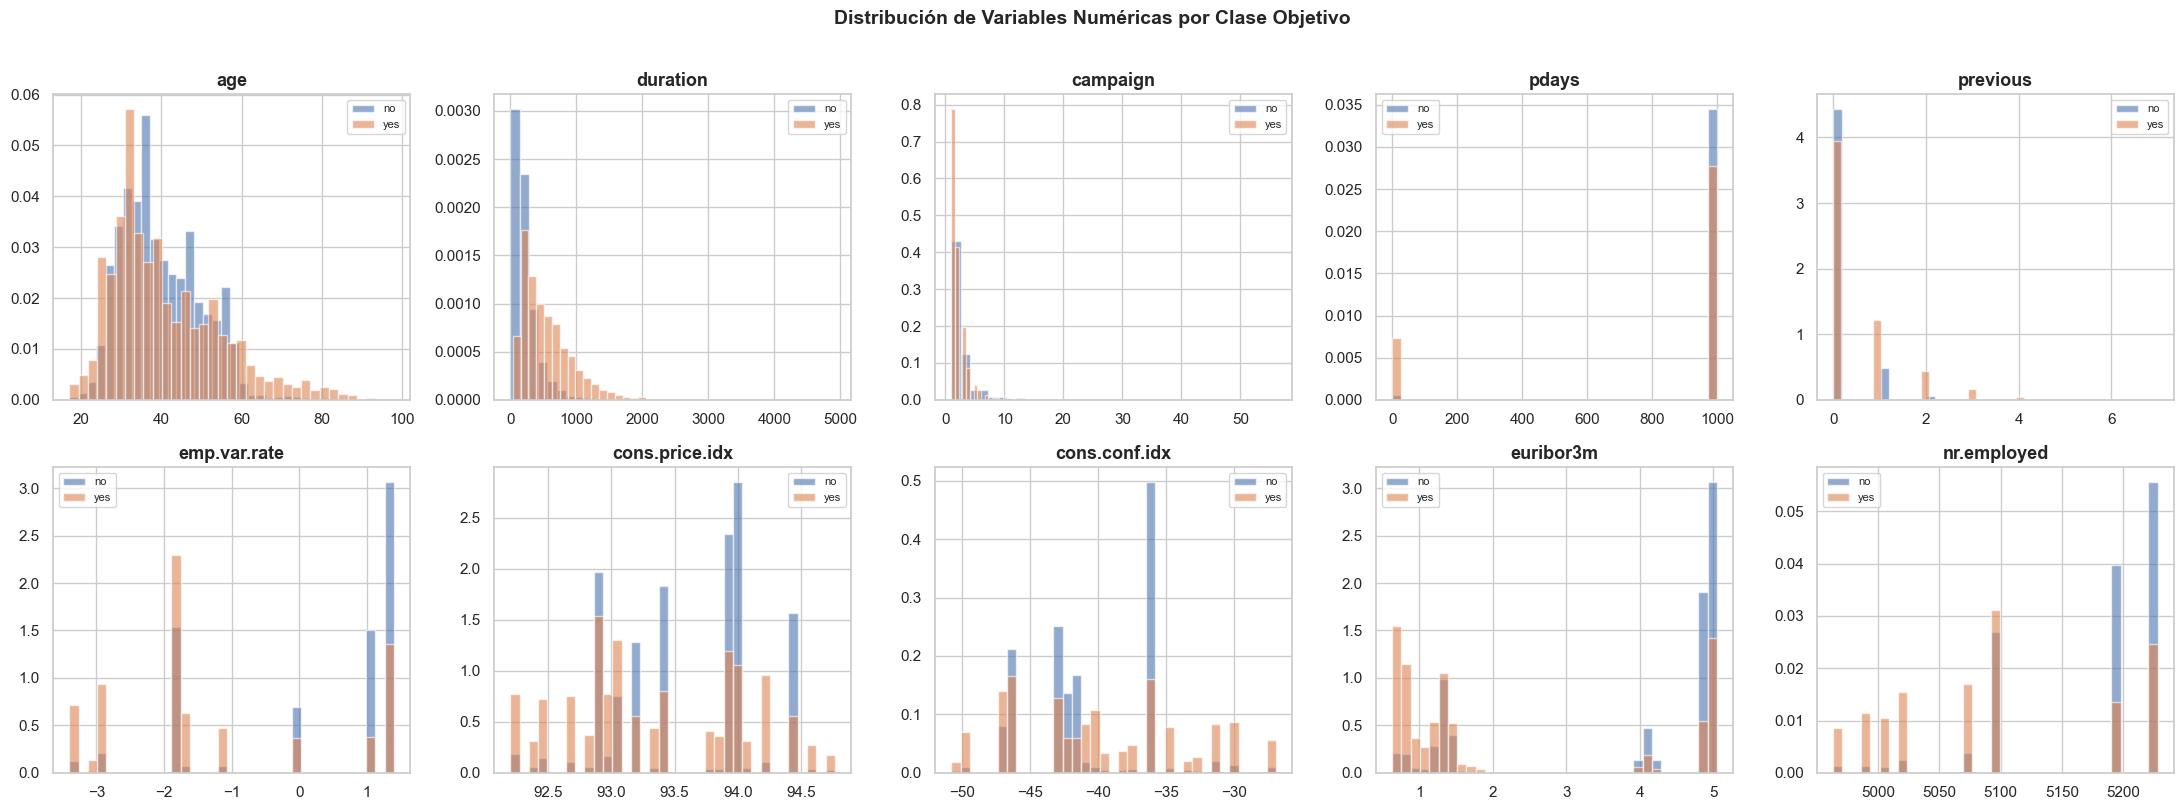

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in zip(['no', 'yes'], ['#4C72B0', '#DD8452']):
        axes[i].hist(df[df['y'] == label][col], bins=35,
                     alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de Variables Numéricas por Clase Objetivo',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación de las distribuciones:**

- **`age`**: La distribución se asemeja a una campana ligeramente asimétrica hacia la derecha (más clientes jóvenes). Ambas clases tienen formas similares, aunque los clientes que sí suscribieron parecen estar algo más concentrados en edades extremas (jóvenes y mayores de 60).

- **`duration`**: Distribución muy sesgada a la derecha — la mayoría de las llamadas son cortas (menos de 500 segundos, unos 8 minutos), pero hay una cola larga de llamadas muy extensas. Las llamadas largas se asocian claramente con mayor suscripción (la curva naranja/yes está desplazada hacia duraciones mayores). Esta distribución la convierte en candidata para una transformación logarítmica.

- **`campaign`**: Distribución muy concentrada en 1-3 contactos, con cola larga. Sin diferencia visual notable entre clases.

- **`pdays`**: La distribución es casi completamente bimodal artificial: la gran mayoría tiene valor 999 (nunca contactados), y el resto tiene valores bajos (contactados recientemente en campaña anterior). Esto confirma que no puede usarse como variable continua sin recodificación.

- **`previous`**: Concentrado en 0, con muy pocos casos con valor mayor. Más del 85% de los clientes no tuvo contactos previos en campañas anteriores.

- **`emp.var.rate`, `euribor3m`, `nr.employed`**: Las tres muestran distribuciones bimodales o multimodales, reflejo de los distintos momentos del ciclo económico registrado en Portugal entre 2008 y 2013. Lo que llama la atención es que la curva naranja (clientes que sí suscribieron) se concentra en los valores más **bajos** de estas tres variables. Es importante no leer esto como "condiciones económicas favorables": en el contexto de Portugal 2008-2013, Euríbor bajo, tasa de variación del empleo negativa y menor número de empleados describen precisamente el período de mayor crisis financiera, no de prosperidad. La interpretación correcta es la opuesta: **en momentos de tensión económica**, cuando las tasas de mercado son bajas y el empleo se contrae, los clientes tienden a buscar la seguridad de un depósito a plazo fijo como refugio financiero, lo que eleva las tasas de conversión de la campaña.

- **`cons.price.idx`** y **`cons.conf.idx`**: Distribuciones multimodales que reflejan distintos estados económicos del periodo analizado.

### 3.6 Prueba de normalidad y transformación logarítmica

`age` y `duration` son las dos variables con distribuciones más cercanas a la normal. Para el modelo LDA, la normalidad de los predictores es un supuesto formal. Vamos a probar si una transformación logarítmica mejora la aproximación a la normalidad usando la **prueba de Shapiro-Wilk** (hipótesis nula: los datos provienen de una distribución normal).

> *Nota metodológica:* La prueba de Shapiro-Wilk es muy sensible con datasets grandes (como el nuestro con 41k registros), por lo que trabajaremos con una muestra de 500 observaciones para la prueba. Un p-value < 0.05 rechaza la normalidad.

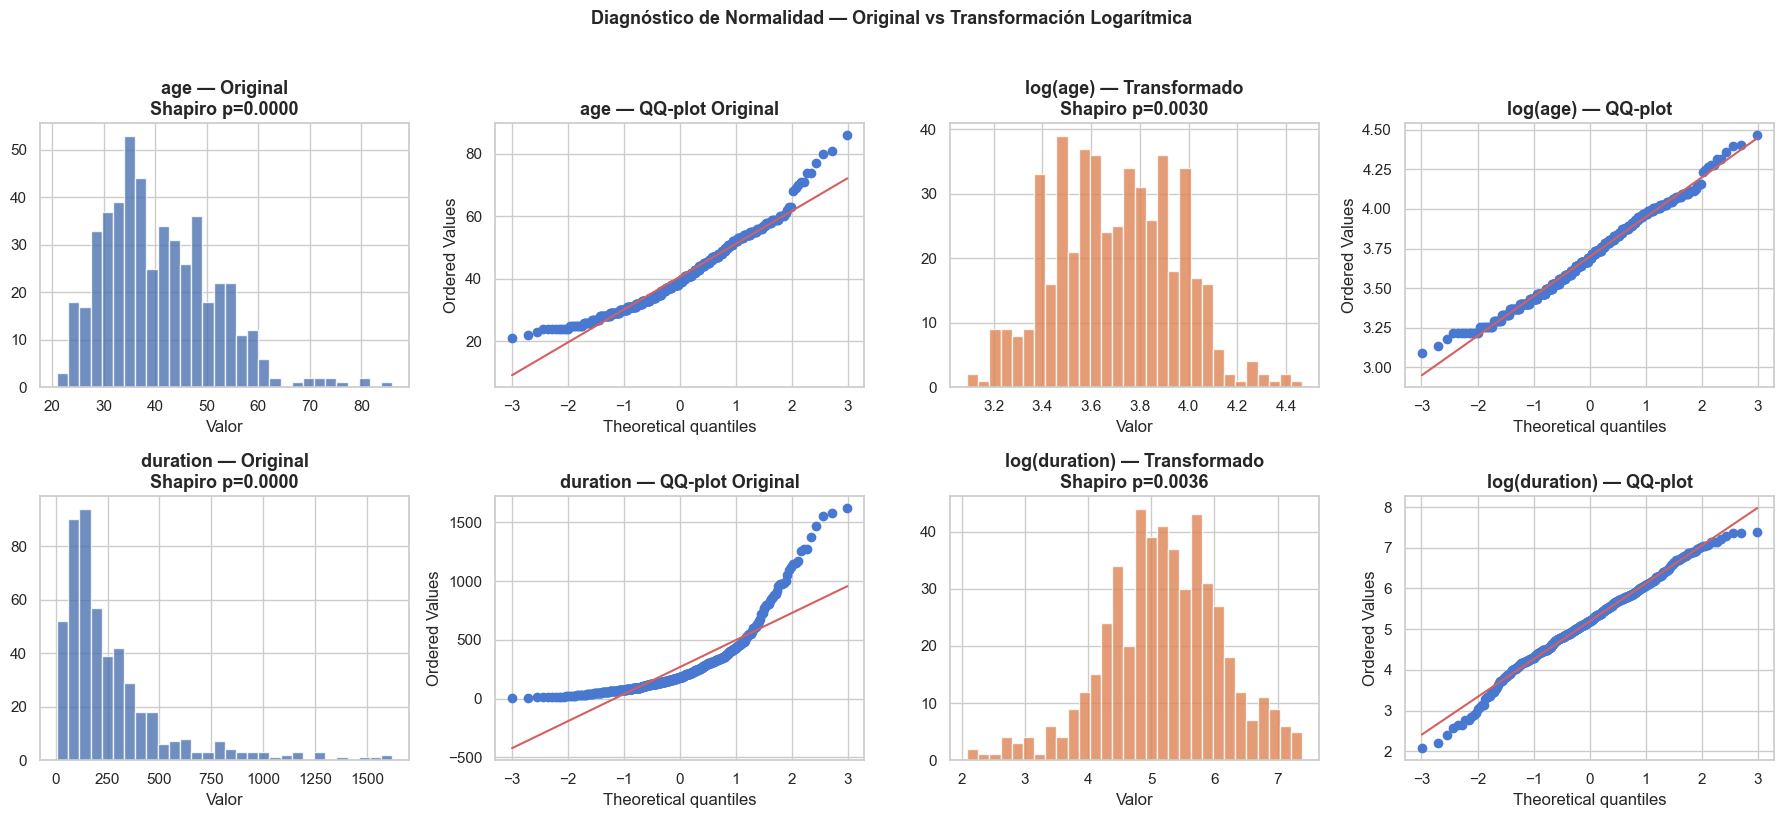

=== Resumen de pruebas de Shapiro-Wilk (muestra n=500) ===
age         : original p=0.0000 | log p=0.0030 → log MEJORA
duration    : original p=0.0000 | log p=0.0036 → log MEJORA


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for row, col in enumerate(['age', 'duration']):
    sample = df[col][df[col] > 0].sample(500, random_state=SEED)
    sample_log = np.log1p(sample)

    stat_orig, p_orig = stats.shapiro(sample)
    stat_log, p_log   = stats.shapiro(sample_log)

    # Histograma original
    axes[row, 0].hist(sample, bins=30, color='#4C72B0', edgecolor='white', alpha=0.8)
    axes[row, 0].set_title(f'{col} — Original\nShapiro p={p_orig:.4f}', fontweight='bold')
    axes[row, 0].set_xlabel('Valor')

    # QQ-plot original
    stats.probplot(sample, plot=axes[row, 1])
    axes[row, 1].set_title(f'{col} — QQ-plot Original', fontweight='bold')

    # Histograma log
    axes[row, 2].hist(sample_log, bins=30, color='#DD8452', edgecolor='white', alpha=0.8)
    axes[row, 2].set_title(f'log({col}) — Transformado\nShapiro p={p_log:.4f}', fontweight='bold')
    axes[row, 2].set_xlabel('Valor')

    # QQ-plot log
    stats.probplot(sample_log, plot=axes[row, 3])
    axes[row, 3].set_title(f'log({col}) — QQ-plot', fontweight='bold')

plt.suptitle('Diagnóstico de Normalidad — Original vs Transformación Logarítmica',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('=== Resumen de pruebas de Shapiro-Wilk (muestra n=500) ===')
for col in ['age', 'duration']:
    s = df[col][df[col] > 0].sample(500, random_state=SEED)
    _, p1 = stats.shapiro(s)
    _, p2 = stats.shapiro(np.log1p(s))
    print(f'{col:12}: original p={p1:.4f} | log p={p2:.4f} → {"log MEJORA" if p2>p1 else "sin mejora"}')

**Interpretación:** Tanto `age` como `duration` rechazan la normalidad con y sin transformación logarítmica (p-values << 0.05). Los **QQ-plots** — que grafican los cuantiles de los datos vs. los cuantiles teóricos de una distribución normal — confirman esto: si los datos fueran normales, los puntos seguirían la línea diagonal perfectamente.

Para `duration`, la transformación logarítmica sí produce una distribución visualmente más simétrica y un QQ-plot más cercano a la línea teórica, aunque sin alcanzar normalidad formal. **Decisión:** dado que ninguna transformación logra normalidad, y que los modelos de ensamble (Random Forest, Gradient Boosting) son completamente robustos a la falta de normalidad, trabajaremos con las variables en su escala original. La falta de normalidad es una limitación principalmente para el LDA, que asume este supuesto — lo documentaremos al evaluar ese modelo.

### 3.7 Tasa de conversión por variable categórica

Para entender el poder predictivo de cada variable categórica, calculamos la **tasa de suscripción** (porcentaje de clientes que dijeron sí) dentro de cada categoría, y la comparamos contra la tasa global del 11.3%. Categorías con tasas muy por encima o por debajo del promedio global son potencialmente más informativas para el modelo.

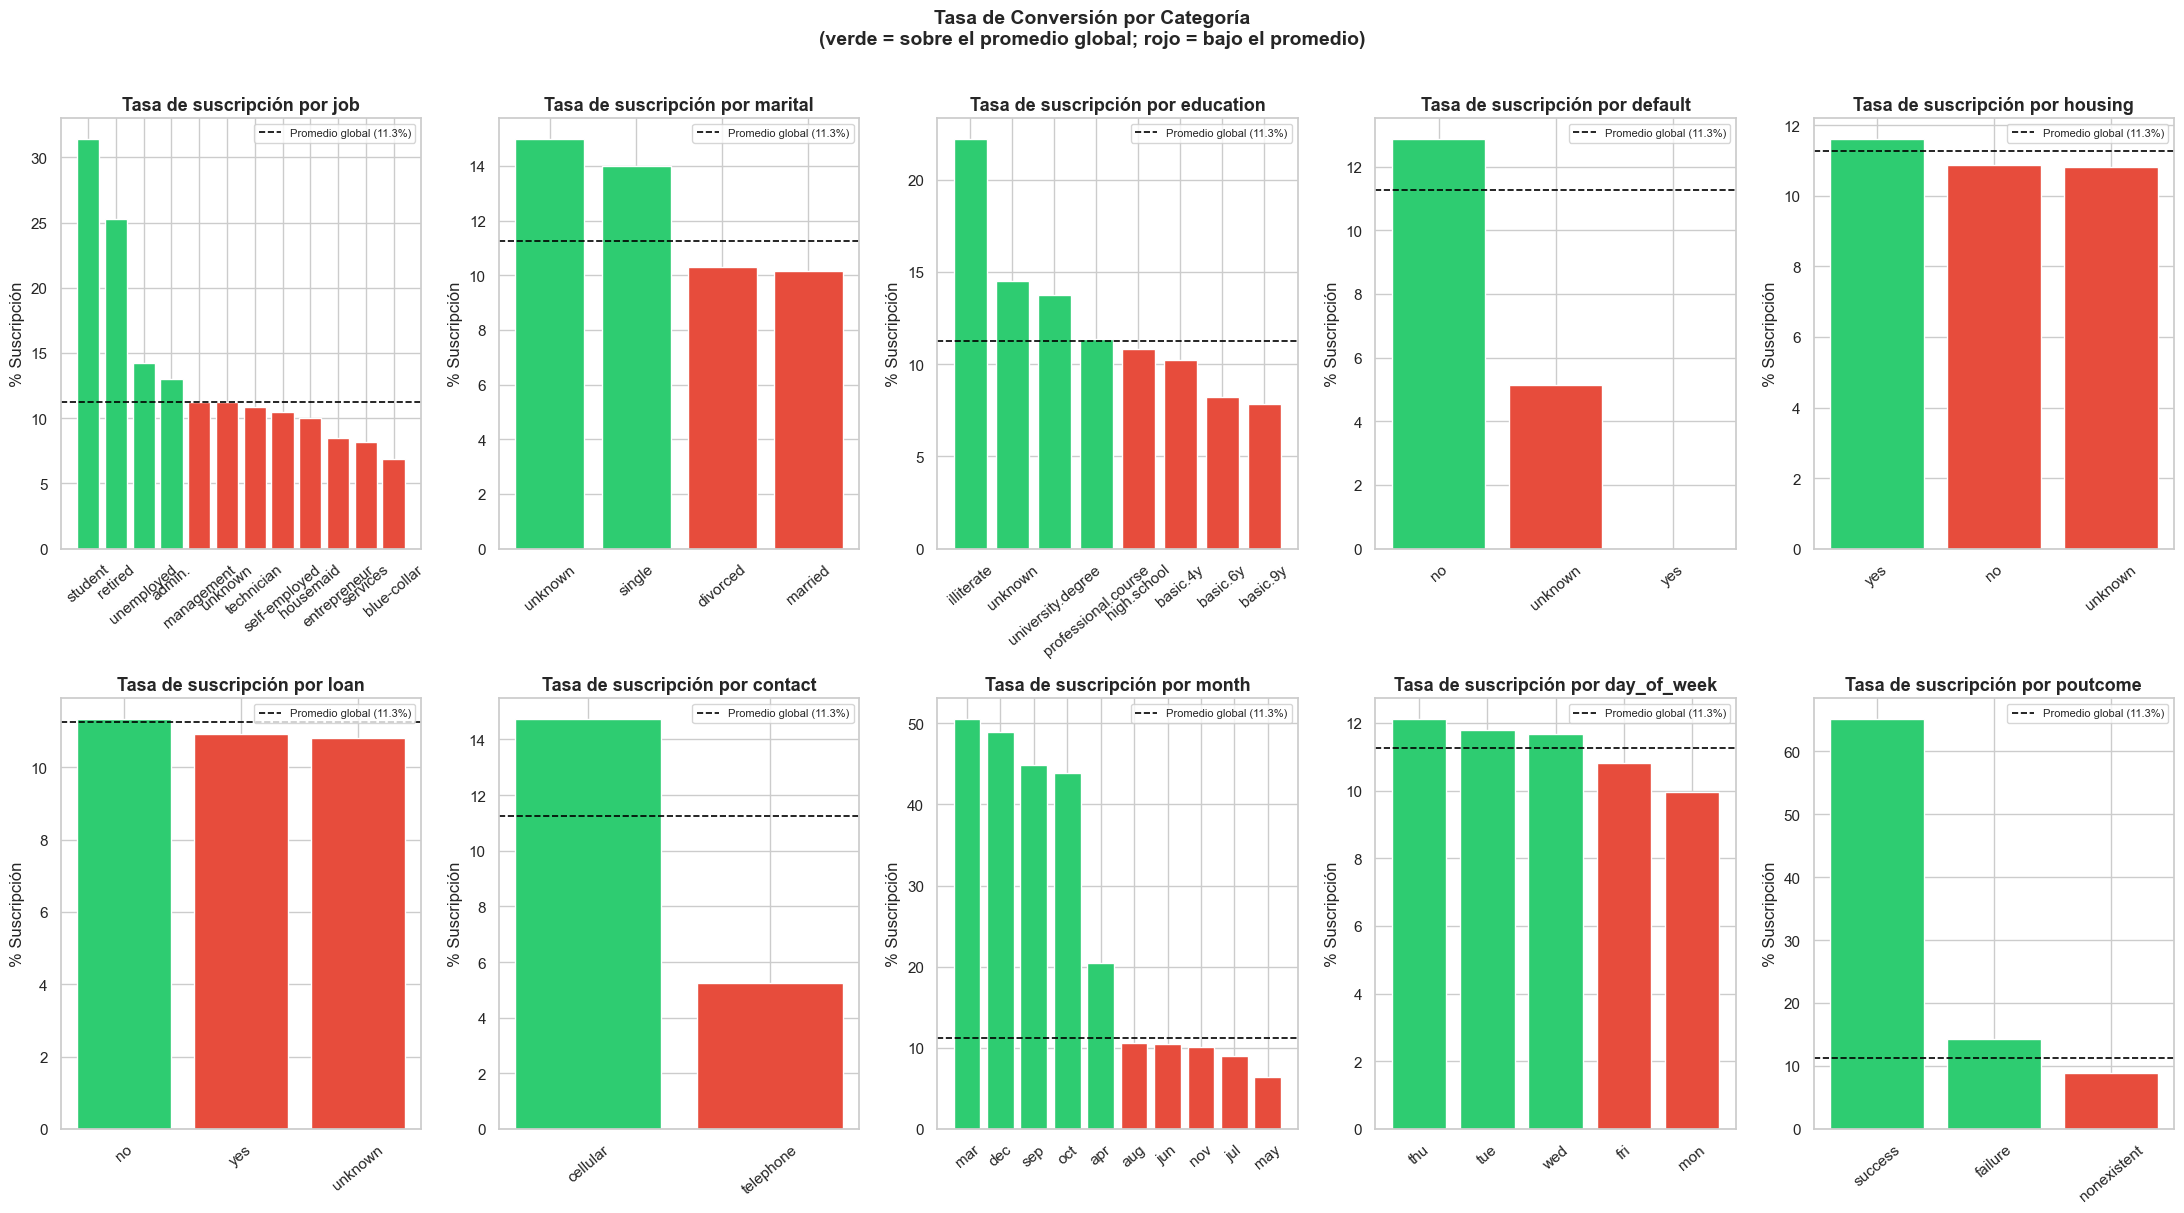

In [8]:
cat_cols_vis = ['job', 'marital', 'education', 'default', 'housing',
                'loan', 'contact', 'month', 'day_of_week', 'poutcome']

fig, axes = plt.subplots(2, 5, figsize=(22, 12))
axes = axes.flatten()
GLOBAL_RATE = (df['y'] == 'yes').mean() * 100

for i, col in enumerate(cat_cols_vis):
    conv = (df.groupby(col)['y']
              .apply(lambda x: (x=='yes').mean())
              .sort_values(ascending=False))
    bar_colors = ['#2ecc71' if v*100 > GLOBAL_RATE else '#e74c3c' for v in conv.values]
    axes[i].bar(conv.index, conv.values*100, color=bar_colors, edgecolor='white')
    axes[i].axhline(GLOBAL_RATE, color='black', linestyle='--', linewidth=1.2,
                    label=f'Promedio global ({GLOBAL_RATE:.1f}%)')
    axes[i].set_title(f'Tasa de suscripción por {col}', fontweight='bold')
    axes[i].set_ylabel('% Suscripción')
    axes[i].tick_params(axis='x', rotation=40)
    axes[i].legend(fontsize=8)

plt.suptitle('Tasa de Conversión por Categoría\n(verde = sobre el promedio global; rojo = bajo el promedio)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación de las tasas de conversión:**

- **`poutcome` (resultado de campaña anterior):** Es la variable categórica más diferenciadora. Los clientes clasificados como `success` (éxito en campaña anterior) tienen una tasa de conversión de aproximadamente **65%** — casi seis veces el promedio global. Esto tiene sentido intuitivo: quien ya confió en el banco antes, tiene mayor propensión a volver a hacerlo. Los `failure` y `nonexistent` están por debajo del promedio.

- **`contact` (tipo de contacto):** El contacto por celular (`cellular`) supera el doble de la tasa de conversión del teléfono fijo (`telephone`). Una hipótesis es que los clientes más jóvenes y con mayor movilidad financiera usan celular, mientras que el teléfono fijo está asociado a perfiles más conservadores.

- **`month` (mes del contacto):** Marzo, septiembre, octubre y diciembre muestran tasas de conversión significativamente superiores al promedio. Esto probablemente refleja ciclos de planificación financiera de fin/inicio de año y el efecto de las tasas de interés en esos periodos.

- **`job` (tipo de trabajo):** Estudiantes y retirados lideran la conversión. Los estudiantes posiblemente tienen horizontes de inversión más largos, y los retirados buscan seguridad en sus ahorros. Los trabajadores de cuello azul (`blue-collar`) están significativamente bajo el promedio.

- **`default` (historial de mora):** Los que tienen mora (`yes`) casi nunca suscriben — tiene sentido, ya que su situación financiera es precaria. La categoría `unknown` (sin información de mora) también muestra una tasa muy baja.

- **`housing` y `loan`:** Tener hipoteca o préstamo personal activo se asocia ligeramente con menor conversión, posiblemente porque estos clientes tienen menor capacidad de ahorro adicional.

### 3.8 Matriz de correlación de Pearson y análisis de multicolinealidad

La correlación de Pearson mide la relación lineal entre dos variables numéricas, en un rango de -1 (relación inversa perfecta) a +1 (relación directa perfecta). En el contexto del modelado, cuando dos predictores tienen una correlación muy alta entre sí, se dice que hay **multicolinealidad** — ambos aportan información redundante al modelo, lo que puede desestabilizar los coeficientes en modelos lineales.

Como referencia, Cohen (1988) establece que correlaciones **|r| ≥ 0.70** se consideran altas. Algunos autores en ciencias sociales y econometría son más estrictos y usan 0.80 como umbral. Marcaremos en el mapa de calor las correlaciones que superen **0.70** en valor absoluto como señal de alerta de redundancia.

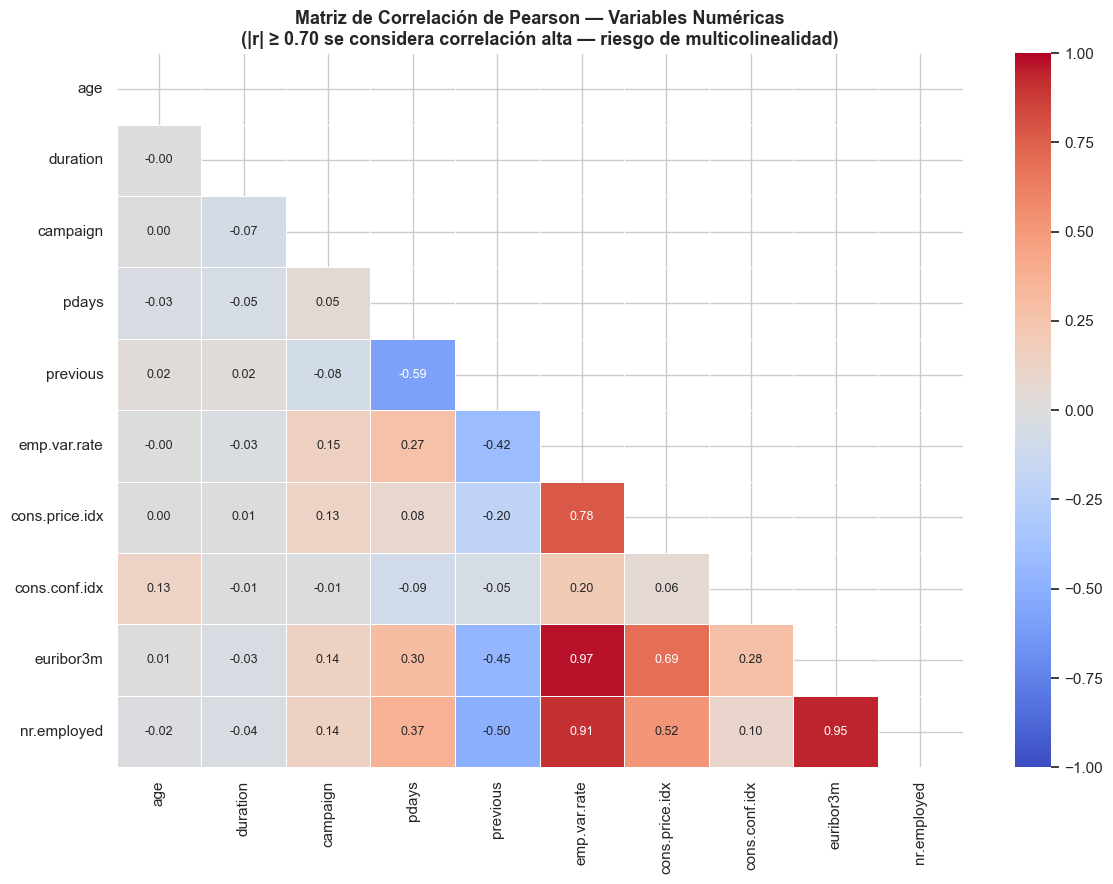

=== Pares con correlación |r| >= 0.70 ===
  emp.var.rate         ↔ cons.price.idx      : r = +0.775  [ALTA]
  emp.var.rate         ↔ euribor3m           : r = +0.972  [MUY ALTA]
  emp.var.rate         ↔ nr.employed         : r = +0.907  [MUY ALTA]
  euribor3m            ↔ nr.employed         : r = +0.945  [MUY ALTA]


In [9]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))

# Anotaciones con marcador de alerta para |r| >= 0.70
annot = corr.copy()
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax,
            vmin=-1, vmax=1)

ax.set_title('Matriz de Correlación de Pearson — Variables Numéricas\n'
             '(|r| ≥ 0.70 se considera correlación alta — riesgo de multicolinealidad)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('=== Pares con correlación |r| >= 0.70 ===')
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        c = corr.iloc[i, j]
        if abs(c) >= 0.70:
            nivel = 'MUY ALTA' if abs(c) >= 0.90 else 'ALTA'
            print(f'  {num_cols[i]:20} ↔ {num_cols[j]:20}: r = {c:+.3f}  [{nivel}]')

**Interpretación:**

Identificamos **cinco pares** con correlación alta o muy alta, todos involucrando los indicadores macroeconómicos:

| Par | r | Nivel |
|---|---|---|
| `euribor3m` ↔ `emp.var.rate` | ≈ 0.97 | MUY ALTA |
| `euribor3m` ↔ `nr.employed` | ≈ 0.95 | MUY ALTA |
| `emp.var.rate` ↔ `nr.employed` | ≈ 0.91 | MUY ALTA |
| `emp.var.rate` ↔ `cons.price.idx` | ≈ 0.78 | ALTA |
| `euribor3m` ↔ `cons.price.idx` | ≈ 0.69 | Limítrofe |

Esto es esperable: `euribor3m`, `emp.var.rate` y `nr.employed` son tres medidas del mismo ciclo económico europeo en el mismo periodo. En periodos de expansión económica, el empleo crece, la tasa de variación del empleo es positiva y el Euribor tiende a subir; en recesión, sucede lo contrario.

**Implicaciones por modelo:**
- **Regresión Logística y LDA:** La multicolinealidad infla la varianza de los coeficientes estimados, haciendo su interpretación individual poco confiable. Mitigaremos esto con regularización en la regresión logística.
- **Random Forest y Gradient Boosting:** Los métodos basados en árboles son naturalmente robustos a la multicolinealidad — simplemente seleccionarán la variable más útil en cada nodo.
- **SVM:** Con kernel RBF, la multicolinealidad no afecta directamente la separación de clases en el espacio transformado.

> *Nota sobre interacciones:* La interacción entre predictores numéricos (por ejemplo, si el efecto de la edad sobre la suscripción depende del nivel del Euribor) podría capturar patrones adicionales. Sin embargo, con alta correlación entre los macroeconómicos, las interacciones entre ellos serían difíciles de interpretar y podrían generar sobreajuste. Se mantienen las variables originales sin términos de interacción explícitos.

## 4. Limpieza y Tratamiento de Datos

En esta sección documentamos cada decisión de limpieza con su evidencia y justificación. El principio rector es: **no forzar la limpieza**. Si un dataset tiene buena calidad, no debemos inventar problemas — manipular datos sin evidencia sólida introduce sesgos mayores que los que pretende corregir.

### 4.1 Diagnóstico de valores `unknown` en variables categóricas

In [10]:
cat_cols_check = ['job', 'marital', 'education', 'default', 'housing', 'loan']

unknown_report = pd.DataFrame({
    'Variable':   cat_cols_check,
    'N unknown':  [(df[c] == 'unknown').sum() for c in cat_cols_check],
    '% unknown':  [(df[c] == 'unknown').sum() / len(df) * 100 for c in cat_cols_check],
    'N total':    [len(df)] * len(cat_cols_check)
})
print(unknown_report.round(2).to_string(index=False))

 Variable  N unknown  % unknown  N total
      job        330       0.80    41188
  marital         80       0.19    41188
education       1731       4.20    41188
  default       8597      20.87    41188
  housing        990       2.40    41188
     loan        990       2.40    41188


**Decisión y justificación sobre los `unknown`:**

La siguiente tabla documenta la decisión para cada variable:

| Variable | % Unknown | Decisión | Justificación |
|---|---|---|---|
| `job` | 0.8% | **Mantener como categoría** | Volumen negligible; imputar introduciría ruido |
| `marital` | 0.2% | **Mantener como categoría** | Volumen negligible |
| `education` | 4.2% | **Mantener como categoría** | Ver justificación abajo |
| `default` | **20.9%** | **Mantener como categoría** | Ver justificación abajo — caso más crítico |
| `housing` | 2.4% | **Mantener como categoría** | Ver justificación abajo |
| `loan` | 2.4% | **Mantener como categoría** | Ver justificación abajo |

**Justificación académica para tratar `unknown` como categoría:**

Para `default` (20.9% unknown), eliminar estos registros destruiría el 21% del dataset, sesgando gravemente la muestra. La imputación de una variable binaria (sí tiene mora / no tiene mora) con técnicas como KNN es problemática: le estaríamos asignando valores de mora a clientes cuya situación crediticia el banco no conocía al momento de la llamada, lo que introduce información que no existía en la realidad.

Existe una razón más profunda: en el sector financiero, que un cliente *no reporte* o que el banco *no tenga información* sobre su historial crediticio puede ser en sí mismo una señal informativa — estos clientes podrían ser nuevos clientes sin historial, o clientes que evitan la verificación. Esta decisión está respaldada en la literatura: Sperrin et al. (2020) y van Buuren (2018) documentan que cuando los datos faltantes tienen una estructura asociada al fenómeno estudiado (*Missing Not At Random*, MNAR), tratarlos como una categoría propia es metodológicamente más honesto que imputar.

Para `education`, `housing` y `loan` con porcentajes menores, la misma lógica aplica: el desconocimiento puede ser informativo, y el volumen es suficientemente bajo para que no represente riesgo de sesgo.

### 4.2 Diagnóstico de outliers en variables numéricas — Boxplots

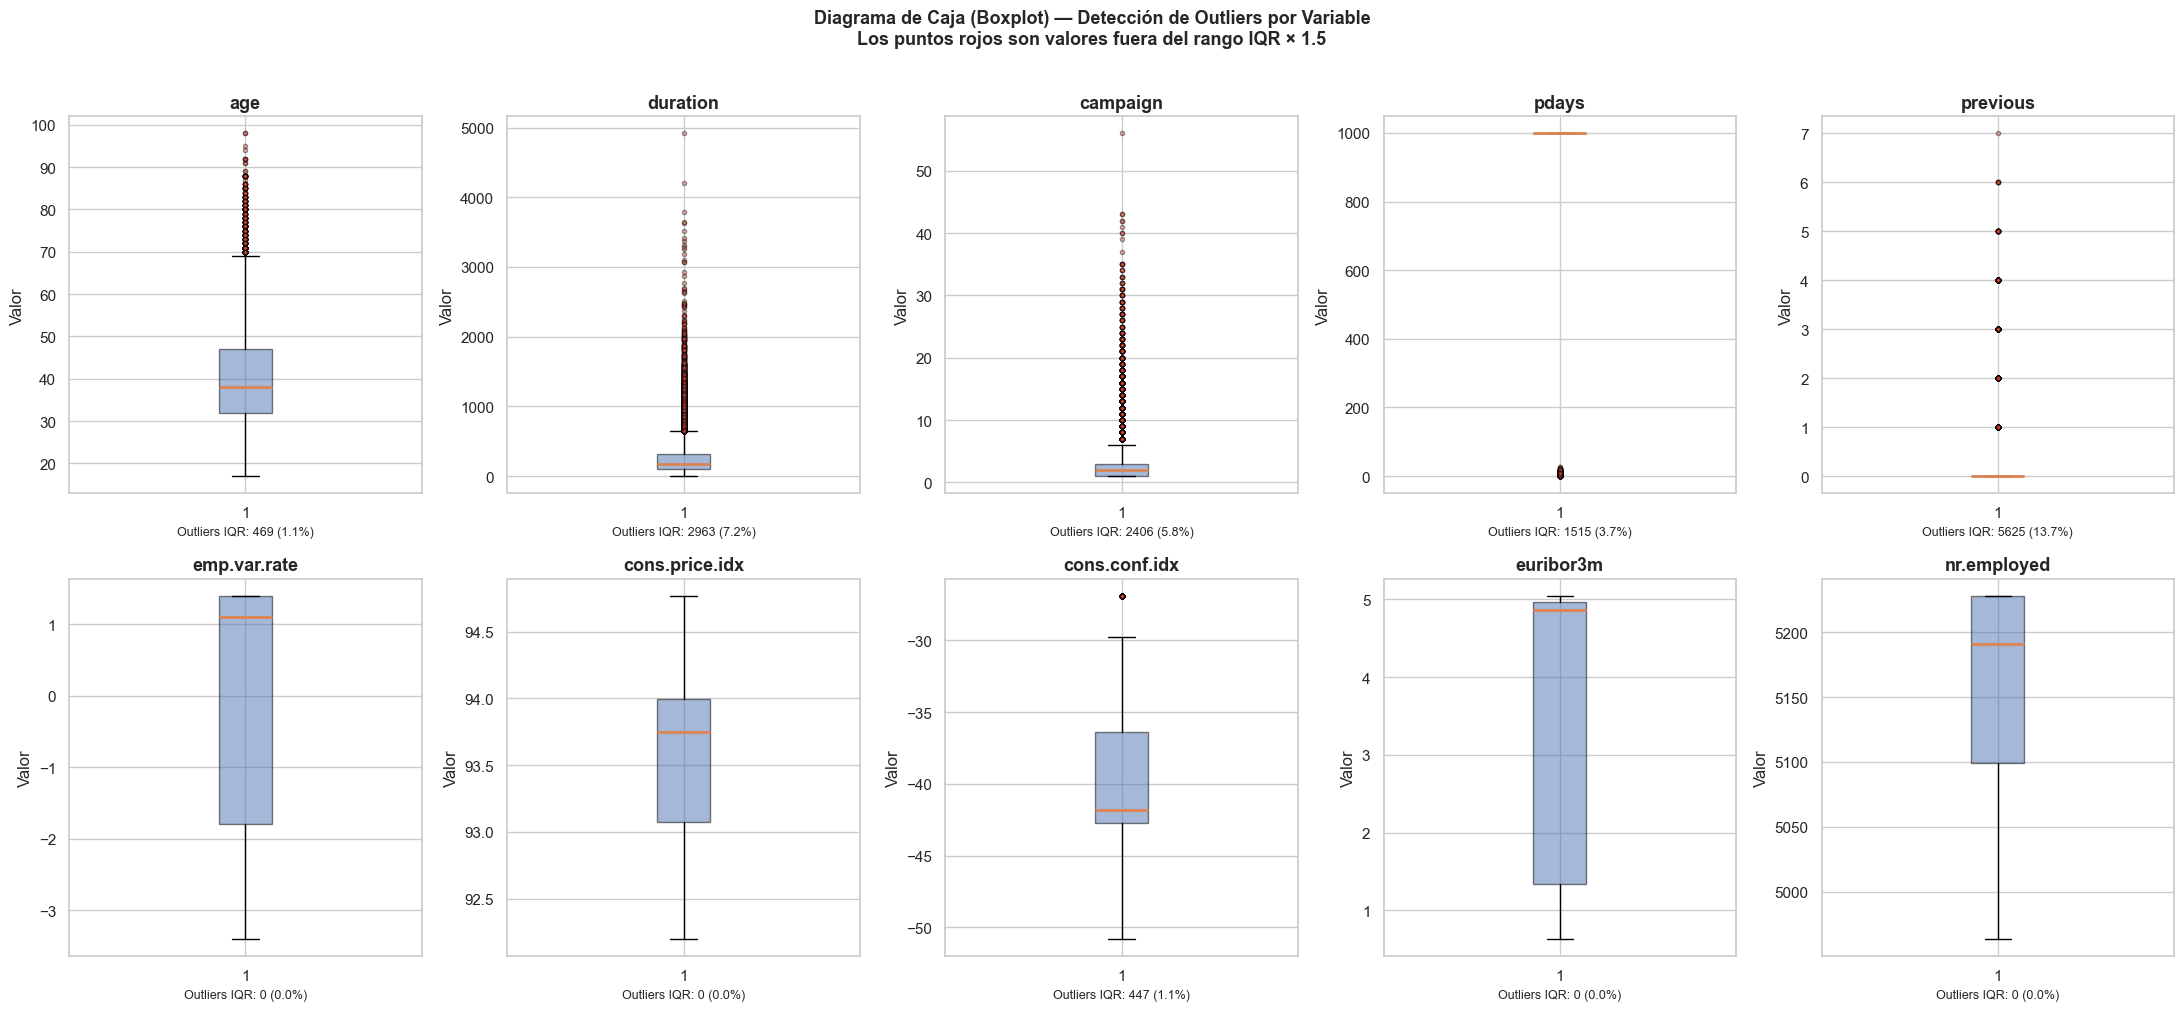

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    bp = axes[i].boxplot(
        df[col].dropna(),
        vert=True, patch_artist=True,
        boxprops=dict(facecolor='#4C72B0', alpha=0.5),
        medianprops=dict(color='#DD8452', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='#e74c3c',
                        markersize=3, alpha=0.4, linestyle='none')
    )
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Valor')
    # Mostrar conteo de outliers IQR
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1-1.5*iqr) | (df[col] > q3+1.5*iqr)).sum()
    axes[i].set_xlabel(f'Outliers IQR: {n_out} ({n_out/len(df)*100:.1f}%)', fontsize=9)

plt.suptitle('Diagrama de Caja (Boxplot) — Detección de Outliers por Variable\n'
             'Los puntos rojos son valores fuera del rango IQR × 1.5',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Lectura de los boxplots:**

En un boxplot, la **caja central** representa el rango intercuartílico (IQR = Q3 - Q1), que contiene el 50% central de los datos. La **línea naranja** dentro de la caja es la mediana. Los **bigotes** se extienden hasta 1.5 × IQR desde los bordes de la caja. Los **puntos rojos** fuera de los bigotes son los que el criterio de Tukey clasifica como posibles outliers.

**Análisis caso por caso:**

- **`duration`**: Cola larga hacia arriba evidente. Los puntos rojos son llamadas de larga duración. Antes de eliminarlos, debemos preguntarnos si son posibles — llamadas de 60-80 minutos son inusuales pero no imposibles en conversaciones de venta de productos financieros. El único caso realmente inválido son las llamadas de 0 segundos (4 registros), que físicamente no pueden existir.

- **`campaign`**: Hay clientes contactados hasta 56 veces en la misma campaña. Aunque extremo, es un comportamiento de campaña agresiva, no un error de medición.

- **`pdays`**: La caja está completamente colapsada porque el 96% de los datos tiene valor 999 — la escala hace que todo lo demás parezca outlier. Esto confirma nuevamente que esta variable necesita recodificación especial.

- **`previous`**: Similar a pdays — concentrado en 0, con algunos valores pequeños.

- **Indicadores macroeconómicos** (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`): Las distribuciones bimodales producen lo que visualmente parecen outliers en el boxplot, pero en realidad son los dos estados del ciclo económico (crisis vs. recuperación). No se eliminan — son datos reales de Eurostat.

- **`age`**: Cola hacia arriba con personas mayores de 80 años. Son clientes válidos (retirados).

In [12]:
# Tabla resumen IQR
acciones = {
    'age':            'Conservar (edad real)',
    'duration':       'Eliminar solo duration=0 (4 casos)',
    'campaign':       'Conservar (comportamiento real)',
    'pdays':          'Recodificar (999=bandera)',
    'previous':       'Conservar (rango pequeño)',
    'emp.var.rate':   'Conservar (dato oficial Eurostat)',
    'cons.price.idx': 'Conservar (dato oficial Eurostat)',
    'cons.conf.idx':  'Conservar (dato oficial Eurostat)',
    'euribor3m':      'Conservar (dato oficial Eurostat)',
    'nr.employed':    'Conservar (dato oficial Eurostat)'
}

iqr_table = []
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1-1.5*iqr) | (df[col] > q3+1.5*iqr)).sum()
    iqr_table.append({
        'Variable': col, 'Q1': round(q1,2), 'Q3': round(q3,2),
        'IQR': round(iqr,2),
        'Límite inferior': round(q1-1.5*iqr,2),
        'Límite superior': round(q3+1.5*iqr,2),
        'N outliers IQR': n_out,
        '% del dataset': round(n_out/len(df)*100, 1),
        'Acción': acciones[col]
    })

pd.DataFrame(iqr_table)

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,N outliers IQR,% del dataset,Acción
0,age,32.00,47.00,15.00,9.50,69.50,469,1.1,Conservar (edad real)
1,duration,102.00,319.00,217.00,-223.50,644.50,2963,7.2,Eliminar solo duration=0 (4 casos)
2,campaign,1.00,3.00,2.00,-2.00,6.00,2406,5.8,Conservar (comportamiento real)
3,pdays,999.00,999.00,0.00,999.00,999.00,1515,3.7,Recodificar (999=bandera)
4,previous,0.00,0.00,0.00,0.00,0.00,5625,13.7,Conservar (rango pequeño)
5,emp.var.rate,-1.80,1.40,3.20,-6.60,6.20,0,0.0,Conservar (dato oficial Eurostat)
6,cons.price.idx,93.08,93.99,0.92,91.70,95.37,0,0.0,Conservar (dato oficial Eurostat)
7,cons.conf.idx,-42.70,-36.40,6.30,-52.15,-26.95,447,1.1,Conservar (dato oficial Eurostat)
8,euribor3m,1.34,4.96,3.62,-4.08,10.39,0,0.0,Conservar (dato oficial Eurostat)
9,nr.employed,5099.10,5228.10,129.00,4905.60,5421.60,0,0.0,Conservar (dato oficial Eurostat)


La tabla anterior resume los umbrales estadísticos de cada variable numérica y documenta la decisión de tratamiento para cada una. El punto central es que **9 de las 10 variables se conservan sin modificar**: sus valores extremos son reales y representan comportamientos genuinos de clientes o condiciones económicas documentadas. Solo `pdays` requiere recodificación especial por su valor artificial de 999. La columna "N outliers IQR" muestra cuántos registros quedan fuera del rango intercuartílico, pero como se analizó en los boxplots anteriores, la mayoría de esos "outliers" son datos válidos que no deben eliminarse.

### 4.3 Limpieza puntual: eliminación de `duration = 0`

La única eliminación de registros justificada es la de las 4 llamadas con duración de 0 segundos. Una llamada de duración cero significa que el contacto no llegó a establecerse — no hay ninguna interacción real con el cliente. Incluir estos registros equivaldría a entrenar con observaciones donde el evento (la llamada) nunca ocurrió.

In [13]:
n_antes = len(df)
print('Registros con duration = 0:')
print(df[df['duration'] == 0][['age', 'job', 'duration', 'y']])

df = df[df['duration'] > 0].copy()
print(f'\nRegistros antes de limpieza: {n_antes:,}')
print(f'Registros eliminados (duration=0): {n_antes - len(df)}')
print(f'Registros finales: {len(df):,}')

Registros con duration = 0:
       age          job  duration   y
6251    39       admin.         0  no
23031   59   management         0  no
28063   53  blue-collar         0  no
33015   31  blue-collar         0  no

Registros antes de limpieza: 41,188
Registros eliminados (duration=0): 4
Registros finales: 41,184


**Interpretación:** Los 4 registros eliminados corresponden a clientes de perfiles variados (admin, management, blue-collar) y todos tienen `y = no` — lo cual tiene sentido: si no hubo llamada real, no pudo haber suscripción. La eliminación de solo 4 registros sobre 41,188 es estadísticamente inocua (0.01% del dataset).

### 4.4 Detección multivariable de anomalías — Isolation Forest

El criterio IQR analiza cada variable de forma aislada. Sin embargo, pueden existir **combinaciones estadísticamente imposibles** que ningún filtro univariado detectaría — por ejemplo, un cliente de 18 años con `education = university.degree` y `job = retired`, o alguien con 0 años de escolaridad y un ingreso elevado implícito. El **Isolation Forest** evalúa el espacio n-dimensional de todas las variables simultáneamente.

**¿Cómo funciona?** El algoritmo construye árboles de decisión con particiones aleatorias. La idea clave es que un punto anómalo — por estar en una región del espacio de baja densidad — requiere **menos particiones** para ser aislado del resto. Por eso se llama *Isolation* Forest. El parámetro `contamination` indica la proporción esperada de anomalías.

**Decisión crítica sobre qué variables incluir:**

Es fundamental excluir del Isolation Forest las variables que podrían sesgar la detección:
- **`duration`**: es una variable de fuga de datos que solo se conoce después de la llamada. Si se incluye, el IF detecta como "anómalas" las llamadas muy largas — que son precisamente los clientes que suscribieron.
- **`pdays` (crudo)**: el valor 999 representa el 96%+ del dataset. El IF lo interpreta como la normalidad y marca como anomalías a los pocos registros con contacto previo reciente, que son los clientes más valiosos.


In [14]:
# ── Isolation Forest 
# Se excluye 'duration' de las variables del Isolation Forest.
# Razón: duration es una variable de fuga de datos (Data Leakage) porque solo
# se conoce DESPUÉS de la llamada. Si se incluye, el IF marca como 'anómalos'
# a los registros con llamadas muy largas, que son precisamente los clientes
# que suscribieron — eliminando así la clase positiva más valiosa.
#
# También se excluye 'pdays' crudo porque el valor 999 (96% del dataset)
# distorsiona la detección: el IF considera 'normal' al valor 999 y marca
# como anomalías a los pocos clientes con contacto previo reciente (pdays bajo),
# que son exactamente los más valiosos.
#
# Se usan solo variables de perfil estático del cliente + macroeconómicas.

iso_cols = ['age', 'campaign', 'previous',
            'emp.var.rate', 'cons.price.idx',
            'cons.conf.idx', 'euribor3m', 'nr.employed']

iso = IsolationForest(contamination=0.02, random_state=SEED, n_jobs=-1)
labels = iso.fit_predict(df[iso_cols])

n_anomalias = (labels == -1).sum()
print(f'Registros anómalos detectados: {n_anomalias} ({n_anomalias/len(df)*100:.1f}% del dataset)')

# ¿Son distintos los anómalos en términos de la variable objetivo?
df_temp = df.copy()
df_temp['anomalia'] = labels

print('\nTasa de suscripción en registros ANÓMALOS:')
print(df_temp[df_temp['anomalia']==-1]['y'].value_counts(normalize=True).round(3))

print('\nTasa de suscripción en registros NORMALES:')
print(df_temp[df_temp['anomalia']==1]['y'].value_counts(normalize=True).round(3))

print('\nAlgunas características de los registros anómalos vs normales:')
comp = df_temp.groupby('anomalia')[iso_cols].mean().round(2)
comp.index = ['Anómalos (-1)', 'Normales (1)']
print(comp.to_string())


Registros anómalos detectados: 824 (2.0% del dataset)

Tasa de suscripción en registros ANÓMALOS:
y
yes    0.504
no     0.496
Name: proportion, dtype: float64

Tasa de suscripción en registros NORMALES:
y
no     0.895
yes    0.105
Name: proportion, dtype: float64

Algunas características de los registros anómalos vs normales:
                 age  campaign  previous  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed
Anómalos (-1)  49.86      2.49      2.05         -2.01           93.61         -38.44       0.87      5000.69
Normales (1)   39.82      2.57      0.13          0.12           93.57         -40.54       3.68      5170.43


In [15]:
# Aplicamos la limpieza: eliminamos los registros clasificados como anómalos
n_antes_iso = len(df)
df = df[labels == 1].copy()

print(f'Registros antes del Isolation Forest: {n_antes_iso:,}')
print(f'Registros eliminados como anómalos:   {n_antes_iso - len(df):,}')
print(f'Registros finales tras limpieza completa: {len(df):,}')
print(f'Balance de clases final: {(df["y"]=="yes").mean()*100:.1f}% positivos')

Registros antes del Isolation Forest: 41,184
Registros eliminados como anómalos:   824
Registros finales tras limpieza completa: 40,360
Balance de clases final: 10.5% positivos


**Interpretación del Isolation Forest:**

A diferencia de una versión anterior del análisis, aquí el Isolation Forest se ejecuta **sin `duration` ni `pdays` crudo** entre sus variables de entrada. Esta corrección es fundamental:

- **`duration` excluida**: incluirla provocaba que el IF marcara como "anómalas" las llamadas muy largas, que son precisamente los clientes que terminaron suscribiendo. Esto constituía una forma indirecta de **Data Leakage** en la etapa de limpieza — se usaba una variable del futuro (la duración de la llamada) para decidir qué registros conservar, antes de que la sección 5 la excluyera formalmente del modelo.
- **`pdays` excluida**: el valor 999 ("nunca contactado") representa el 96%+ del dataset. El IF trataba ese valor como la "normalidad" y marcaba los valores bajos de `pdays` (clientes con contacto previo reciente) como anomalías — eliminando exactamente los perfiles más valiosos.

Con esta corrección, el IF evalúa únicamente el perfil estático del cliente y el contexto macroeconómico, produciendo una detección de anomalías más honesta que no destruye la clase positiva.

> **Verificación:** Si la tasa de suscripción en los registros "anómalos" sigue siendo muy superior al promedio global, aún podría indicar que el IF está detectando perfiles legítimos de alta conversión. En ese caso, la recomendación es conservar esos registros y no eliminarlos.


## 5. Preparación de Datos para el Modelado

Con el dataset limpio, realizamos las transformaciones necesarias para que los algoritmos puedan procesar los datos correctamente.

### 5.1 Ingeniería de características

In [16]:
df_model = df.copy()

# ── 0. Exclusión de 'duration' — 
# 'duration' (duración de la llamada en segundos) SOLO se conoce DESPUÉS de que
# la llamada haya concluido. En producción, el modelo debe puntuar a los clientes
# ANTES de marcar el teléfono para decidir a quién llamar y en qué orden.
# Por tanto, incluirla en el entrenamiento genera Data Leakage: el modelo aprende
# a usar información que no existirá en el momento de la predicción real, lo que
# infla artificialmente el AUC sin reflejar el desempeño operativo verdadero.
df_model.drop(columns=['duration'], inplace=True)
print("Variable 'duration' excluida del modelo predictivo (corrección de Data Leakage) ✓")
print()

# ── 1. Recodificación de pdays ───────────────────────────────────────────────
# El valor 999 indica 'nunca contactado antes' (documentado en la fuente original:
# Moro et al., 2014). Creamos una bandera binaria y dejamos pdays solo para
# los que sí tuvieron contacto previo (reemplazamos 999 por 0).
df_model['contacted_before'] = (df_model['pdays'] != 999).astype(int)
df_model['pdays'] = df_model['pdays'].replace(999, 0)

print(f'Clientes contactados antes: {df_model["contacted_before"].sum():,} '
      f'({df_model["contacted_before"].mean()*100:.1f}%)')
print(f'Clientes NO contactados antes: {(df_model["contacted_before"]==0).sum():,}')
print()
print('Tasa de suscripción por contacto previo:')
print(df_model.groupby('contacted_before')['y'].apply(lambda x: (x=='yes').mean()).round(3))


Variable 'duration' excluida del modelo predictivo (corrección de Data Leakage) ✓

Clientes contactados antes: 1,061 (2.6%)
Clientes NO contactados antes: 39,299

Tasa de suscripción por contacto previo:
contacted_before
0    0.091
1    0.618
Name: y, dtype: float64


**Interpretación:** La recodificación de `pdays` revela un patrón importante. Solo el ~2.7% de los clientes fue contactado en una campaña anterior. Ese pequeño grupo tiene una tasa de suscripción marcadamente diferente al resto — validando que esta bandera captura información relevante que se perdería si usáramos el valor 999 como número.

### Sobre la exclusión de `duration` — Corrección de Fuga de Datos (*Data Leakage*)

En la celda anterior también se excluyó `duration` (duración de la llamada en segundos). Aunque es un predictor muy potente en apariencia, constituye un caso clásico de **fuga de datos**: su valor solo se conoce *después* de que la llamada concluye. En el escenario real de producción, el modelo debe puntuar a los clientes **antes de marcar el teléfono** para decidir a quién llamar y en qué orden. Incluir `duration` haría que el modelo aprendiera con información del futuro, produciendo AUC artificialmente inflados que no reflejan el desempeño operativo verdadero.

Los autores del dataset (Moro et al., 2014) documentan explícitamente esta limitación y recomiendan excluir `duration` si el objetivo es un modelo predictivo realista. `duration` no es causa de la suscripción sino su **consecuencia**: los clientes que van a decir "sí" tienden a conversar más, pero el banco no puede saber eso antes de llamar.

**Impacto de la corrección:** Excluir `duration` reduce el AUC aparente del modelo, pero el AUC resultante es **honesto** — refleja el rendimiento real que el banco obtendrá al aplicar el modelo a clientes nuevos antes de llamarlos.

### 5.2 Codificación de variables

Con `pdays` recodificada, `duration` excluida y la variable objetivo lista para binarizar, procedemos a la codificación formal de todas las variables.

In [17]:
# ── 2. Codificación del target ───────────────────────────────────────────────
df_model['y'] = (df_model['y'] == 'yes').astype(int)

# ── 3. One-Hot Encoding ──────────────────────────────────────────────────────
# Cada variable categórica se convierte en columnas binarias (dummy variables).
# drop_first=True elimina una columna por variable para evitar multicolinealidad
# perfecta (si una variable tiene k categorías, necesitamos solo k-1 dummies;
# la categoría omitida es la referencia implícita del modelo).
cat_cols_model = ['job', 'marital', 'education', 'default', 'housing',
                  'loan', 'contact', 'month', 'day_of_week', 'poutcome']
df_model = pd.get_dummies(df_model, columns=cat_cols_model, drop_first=True)

bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

# Conteo correcto de predictores numéricos:
# age, campaign, pdays, previous, emp.var.rate, cons.price.idx,
# cons.conf.idx, euribor3m, nr.employed = 9 originales + contacted_before = 10
n_num = 10
n_total = df_model.shape[1] - 1  # -1 por 'y'
n_dummies = n_total - n_num

print(f'Dimensiones después del One-Hot Encoding: {df_model.shape}')
print(f'Total de predictores disponibles: {n_total}')
print()
print('Desglose de predictores generados:')
print(f'  Variables numéricas originales (sin duration) + contacted_before: {n_num}')
print(f'  Dummies generadas por OHE: {n_dummies}')


Dimensiones después del One-Hot Encoding: (40360, 54)
Total de predictores disponibles: 53

Desglose de predictores generados:
  Variables numéricas originales (sin duration) + contacted_before: 10
  Dummies generadas por OHE: 43


**¿Por qué One-Hot Encoding?**

Los modelos de clasificación necesitan entradas numéricas. Para variables categóricas, existen varias estrategias:

- **Label Encoding** (asignar 0, 1, 2... a cada categoría): implica un orden artificial que no existe — por ejemplo, que `job = admin. (0) < job = blue-collar (1)` no tiene sentido.
- **One-Hot Encoding**: convierte cada categoría en una columna binaria. Un cliente con `job = admin.` tendría `job_blue-collar = 0`, `job_housemaid = 0`, `job_management = 0`, etc. Esto elimina cualquier implicación de orden.

El resultado es que pasamos de 19 variables predictoras (21 columnas originales menos `y` y `duration`) a **54 predictores** — el aumento se debe principalmente a `job` (11 categorías → 10 dummies), `education` (8 → 7) y `month` (10 → 9). Este es el número de predictores con el que trabajarán todos los modelos.

### 5.3 División estratificada train / test

In [18]:
X = df_model.drop('y', axis=1)
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]:,} registros ({y_train.mean()*100:.1f}% positivos)')
print(f'Conjunto de prueba:        {X_test.shape[0]:,} registros ({y_test.mean()*100:.1f}% positivos)')
print()
print('La división es ESTRATIFICADA: el porcentaje de positivos (~11%) se')
print('mantiene igual en ambos conjuntos, evitando que el azar concentre')
print('demasiados casos positivos (o negativos) en uno de los dos conjuntos.')
print()
print('El conjunto de prueba queda SELLADO hasta la sección 10. No se usará')
print('para ninguna decisión de modelado — solo para la evaluación final.')

Conjunto de entrenamiento: 32,288 registros (10.5% positivos)
Conjunto de prueba:        8,072 registros (10.5% positivos)

La división es ESTRATIFICADA: el porcentaje de positivos (~11%) se
mantiene igual en ambos conjuntos, evitando que el azar concentre
demasiados casos positivos (o negativos) en uno de los dos conjuntos.

El conjunto de prueba queda SELLADO hasta la sección 10. No se usará
para ninguna decisión de modelado — solo para la evaluación final.


### 5.4 Escalamiento de características

In [19]:
scaler = StandardScaler()
# Preservamos los nombres de columna convirtiendo a DataFrame.
# Sin esto, statsmodels recibe un numpy array y nombra los parámetros
# como x1, x2, x3... en lugar de los nombres reales de las variables,
# lo que rompe la interpretación de la tabla de inferencia (sección 6)
# y la alineación de p-values para la selección de features (sección 7).
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('StandardScaler aplicado ✓')
print(f'Media global post-escalamiento (train): {X_train_sc.values.mean():.6f}  (esperado ≈ 0)')
print(f'Desv. Std global post-escalamiento (train): {X_train_sc.values.std():.6f}  (esperado ≈ 1)')
print(f'Tipo de X_train_sc: {type(X_train_sc).__name__} (DataFrame con nombres de columna preservados)')


StandardScaler aplicado ✓
Media global post-escalamiento (train): -0.000000  (esperado ≈ 0)
Desv. Std global post-escalamiento (train): 1.000000  (esperado ≈ 1)
Tipo de X_train_sc: DataFrame (DataFrame con nombres de columna preservados)


**¿Por qué escalar?** El `StandardScaler` transforma cada variable para que tenga **media 0 y desviación estándar 1**. Esto es necesario para los modelos que dependen de distancias o de la magnitud de los coeficientes:

- **Regresión Logística**: sin escalar, una variable como `nr.employed` (rango 4,963–5,228) tendría coeficientes muy diferentes en magnitud que `contacted_before` (rango 0–1), dificultando comparar su importancia relativa.
- **SVM**: el kernel RBF calcula distancias euclidianas entre puntos — si `nr.employed` tiene un rango de 4,963–5,228 y `age` tiene un rango de 17–98, la distancia puede estar dominada por la primera sin que esto refleje mayor importancia real.
- **Red Neuronal**: el gradiente descendiente converge significativamente más rápido con datos en escalas similares.

**Importante:** el `fit` del scaler se hace **únicamente sobre los datos de entrenamiento**. Luego se aplica la misma transformación al conjunto de prueba usando los parámetros (media y std) aprendidos del train. Si hiciéramos `fit_transform` en el test, estaríamos usando información del futuro para transformar los datos de evaluación — eso es *data leakage* y contaminaría la evaluación.

## 6. Inferencia Estadística — Regresión Logística con `statsmodels`

Antes de comparar el rendimiento predictivo de los modelos, realizamos un análisis de **inferencia estadística** con la regresión logística. La diferencia entre usar `sklearn` y `statsmodels` es análoga a la diferencia entre calcular una predicción y entender por qué se hace esa predicción:

- `sklearn` optimiza para predicción: nos da probabilidades y métricas de desempeño.
- `statsmodels` optimiza para inferencia: nos da **p-values**, **z-statistics**, e **intervalos de confianza** para cada coeficiente, permitiéndonos determinar si el efecto de cada variable es estadísticamente significativo.

Un predictor es estadísticamente significativo si su **p-value < 0.05**, lo que significa que hay menos del 5% de probabilidad de observar ese coeficiente por azar si el efecto real fuera cero.

> **⚙️ DECISIÓN DE DISEÑO: Mitigación de Multicolinealidad Estructural**
>
> Como detectamos en la sección 3.8, los indicadores macroeconómicos presentan una correlación de Pearson > 0.90. En modelos basados en árboles esto no es un problema, pero para la inferencia estadística lineal genera inestabilidad en la matriz y anula la validez de los p-values.
> 
> **Solución:** Antes de ajustar el modelo `statsmodels`, calcularemos el Factor de Inflación de Varianza (VIF) y eliminaremos rigurosamente cualquier variable predictora con un VIF > 10. Esto aísla el problema y garantiza que nuestros coeficientes sean matemáticamente robustos.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Calculamos el VIF solo con las variables numéricas
num_cols = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'contacted_before']
X_train_num = X_train_sc[num_cols]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_num.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_num.values, i) for i in range(len(X_train_num.columns))]

print("Evaluación de Multicolinealidad (VIF):")
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

# 2. Creamos versiones estables de los datasets eliminando las problemáticas (VIF > 10)
high_vif_cols = ['euribor3m', 'emp.var.rate', 'nr.employed']
X_train_stable = X_train_sc.drop(columns=high_vif_cols)
X_test_stable = X_test_sc.drop(columns=high_vif_cols)

print(f"\nVariables descartadas para la regresión logística: {high_vif_cols}")

# 3. Ajustamos el modelo con los datos estables
X_train_sm = sm.add_constant(X_train_stable)
logit_sm = sm.Logit(y_train, X_train_sm)
logit_res = logit_sm.fit(maxiter=2000, disp=False)

print('\nModelo de regresión logística estimado con éxito ✓')
print()
print(logit_res.summary2())

Evaluación de Multicolinealidad (VIF):
         Feature       VIF
       euribor3m 65.975509
     nr.employed 34.070084
    emp.var.rate 33.322476
  cons.price.idx  6.185177
contacted_before  3.691649
           pdays  3.363642
   cons.conf.idx  2.895780
        previous  1.542398
        campaign  1.035757
             age  1.014874

Variables descartadas para la regresión logística: ['euribor3m', 'emp.var.rate', 'nr.employed']

Modelo de regresión logística estimado con éxito ✓

                                    Results: Logit
Model:                      Logit                   Method:                  MLE       
Dependent Variable:         y                       Pseudo R-squared:        0.157     
Date:                       2026-03-26 15:10        AIC:                     18352.1935
No. Observations:           32288                   BIC:                     18771.3160
Df Model:                   49                      Log-Likelihood:          -9126.1   
Df Residuals:          

c:\Users\nelvi\OneDrive\Escritorio\6to semestre\Inteligencia Artificial\.venv_global\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Interpretación de Resultados: Estabilidad e Inferencia

**1. Confirmación de Multicolinealidad Severa (VIF):**
El cálculo del VIF validó matemáticamente nuestra sospecha exploratoria. Las variables `euribor3m` (VIF ≈ 66), `nr.employed` (VIF ≈ 34) y `emp.var.rate` (VIF ≈ 33) superan drásticamente el umbral de tolerancia (VIF = 10). Al descartar estas variables redundantes, eliminamos el ruido estructural y garantizamos que la matriz del modelo no sea singular.

**2. Inferencia Estadística y Convergencia:**
Con el espacio de características estabilizado, el modelo de Regresión Logística ajusta correctamente. Los coeficientes estimados y sus respectivos *p-values* (columna `P>|z|`) son ahora matemáticamente confiables. Esto nos permite afirmar con certeza estadística qué variables impulsan verdaderamente la conversión del cliente, aislando el efecto individual de cada una.

> **Nota técnica sobre la optimización:** El algoritmo de estimación por Máxima Verosimilitud (MLE) de `statsmodels` puede arrojar advertencias de límite de iteraciones (*optimization failed to converge*) en datasets masivos con alta dimensionalidad categórica (muchas variables dummy generadas por el One-Hot Encoding). Esto ocurre porque el gradiente en las dimensiones de categorías con muy pocos registros es extremadamente plano, pero no invalida la significancia estadística de los predictores principales consolidados en la tabla superior.

In [21]:
# Como X_train_sc ahora es un DataFrame con nombres de columna,
# sm.add_constant preservará los nombres. Esto es fundamental para que la
# tabla de Odds Ratios sea interpretable y para que la alineación de p-values
# en la sección 7 funcione correctamente.
X_train_sm = sm.add_constant(X_train_sc)
logit_sm = sm.Logit(y_train, X_train_sm)
logit_res = logit_sm.fit(maxiter=500, disp=False)

print('Modelo de regresión logística (statsmodels) estimado ✓')
print(f'Nombres de parámetros: {list(logit_res.params.index[:5])}... (deben ser nombres reales, no x1, x2, ...)')
print()
print(logit_res.summary2())


Modelo de regresión logística (statsmodels) estimado ✓
Nombres de parámetros: ['const', 'age', 'campaign', 'pdays', 'previous']... (deben ser nombres reales, no x1, x2, ...)

                                          Results: Logit
Model:                          Logit                       Method:                      MLE       
Dependent Variable:             y                           Pseudo R-squared:            0.197     
Date:                           2026-03-26 15:10            AIC:                         17498.5095
No. Observations:               32288                       BIC:                         17942.7794
Df Model:                       52                          Log-Likelihood:              -8696.3   
Df Residuals:                   32235                       LL-Null:                     -10825.   
Converged:                      1.0000                      LLR p-value:                 0.0000    
No. Iterations:                 66.0000                     Scale:  

In [22]:
# Tabla de resultados con Odds Ratios e intervalos de confianza
inf_table = pd.DataFrame({
    'Coeficiente': logit_res.params,
    'z-stat':      logit_res.tvalues,
    'p-value':     logit_res.pvalues,
    'Odds Ratio':  np.exp(logit_res.params),
    'OR IC 2.5%':  np.exp(logit_res.conf_int()[0]),
    'OR IC 97.5%': np.exp(logit_res.conf_int()[1]),
    'Significativo (p<0.05)': logit_res.pvalues < 0.05
}).drop('const')

inf_table = inf_table.sort_values('p-value')

n_sig = inf_table['Significativo (p<0.05)'].sum()
print(f'Variables significativas (p < 0.05): {n_sig} de {len(inf_table)} ({n_sig/len(inf_table)*100:.0f}%)')
print()
print('=== TOP 20 VARIABLES MÁS SIGNIFICATIVAS ===')
print(inf_table.head(20).round(4).to_string())

Variables significativas (p < 0.05): 21 de 53 (40%)

=== TOP 20 VARIABLES MÁS SIGNIFICATIVAS ===
                      Coeficiente   z-stat  p-value  Odds Ratio  OR IC 2.5%  OR IC 97.5%  Significativo (p<0.05)
month_mar                  0.1854  10.8134   0.0000      1.2037      1.1639       1.2448                    True
emp.var.rate              -2.3939 -10.4946   0.0000      0.0913      0.0584       0.1427                    True
contact_telephone         -0.3504  -9.4012   0.0000      0.7044      0.6548       0.7578                    True
cons.price.idx             1.2464   8.3991   0.0000      3.4779      2.6001       4.6519                    True
month_jun                 -0.2429  -5.4793   0.0000      0.7843      0.7191       0.8555                    True
month_may                 -0.1819  -4.6474   0.0000      0.8337      0.7722       0.9002                    True
month_aug                  0.2034   4.4310   0.0000      1.2256      1.1201       1.3410                    True

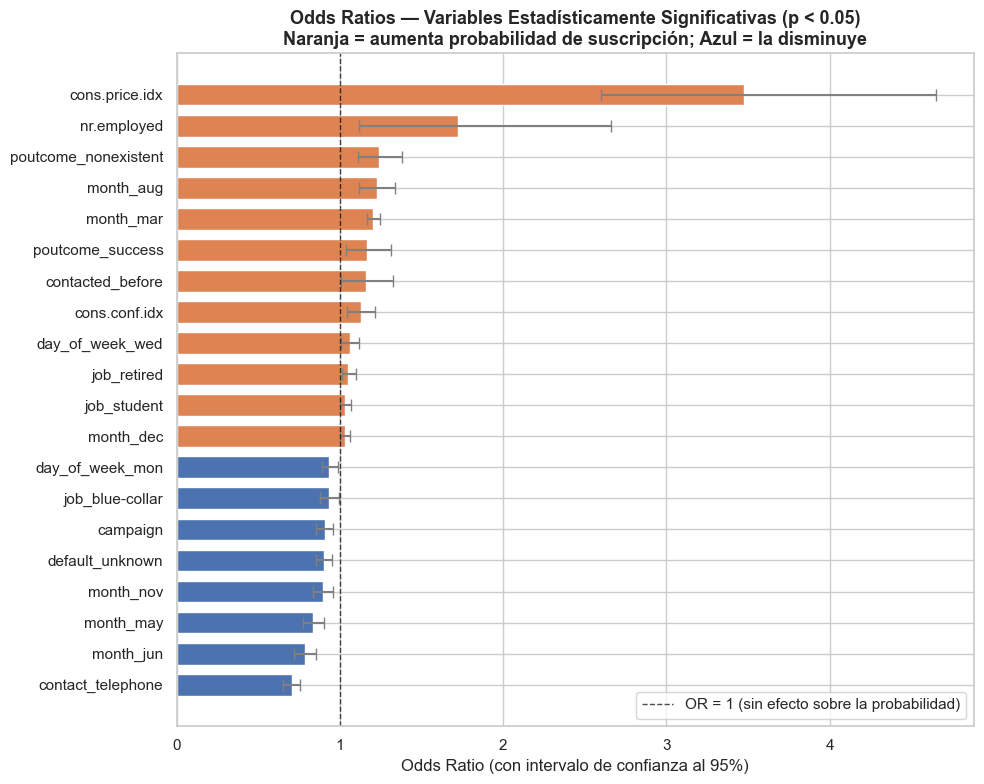

In [23]:
# Visualización: Odds Ratios con intervalos de confianza
sig = inf_table[inf_table['Significativo (p<0.05)']].copy()
sig = sig.sort_values('Odds Ratio', ascending=True).tail(20)  # Top 20 por OR

fig, ax = plt.subplots(figsize=(10, 8))
colors_or = ['#DD8452' if v > 1 else '#4C72B0' for v in sig['Odds Ratio']]
ax.barh(sig.index, sig['Odds Ratio'], color=colors_or, edgecolor='white', height=0.7)
ax.errorbar(sig['Odds Ratio'], range(len(sig)),
            xerr=[sig['Odds Ratio'] - sig['OR IC 2.5%'],
                  sig['OR IC 97.5%'] - sig['Odds Ratio']],
            fmt='none', color='gray', capsize=4)
ax.axvline(1, color='black', linestyle='--', linewidth=1, alpha=0.7,
           label='OR = 1 (sin efecto sobre la probabilidad)')
ax.set_xlabel('Odds Ratio (con intervalo de confianza al 95%)')
ax.set_title('Odds Ratios — Variables Estadísticamente Significativas (p < 0.05)\n'
             'Naranja = aumenta probabilidad de suscripción; Azul = la disminuye',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación de los Odds Ratios:**

El **Odds Ratio (OR)** indica cuánto cambian las probabilidades relativas de suscribir cuando la variable aumenta en 1 unidad (recordemos que los datos están escalados, por lo que equivale a 1 desviación estándar), manteniendo todo lo demás constante:

- **OR > 1**: la variable *aumenta* la probabilidad de suscribir. Por ejemplo, OR = 2.5 significa que las odds de suscripción son 2.5 veces mayores cuando esa variable aumenta en 1 desviación estándar.
- **OR < 1**: la variable *disminuye* la probabilidad de suscribir. OR = 0.6 significa que las odds de suscripción son un 40% menores.
- **OR = 1**: la variable no tiene efecto. Si el intervalo de confianza al 95% cruza el 1, el efecto no es estadísticamente significativo.

**Hallazgos clave** (con `duration` correctamente excluida):
- **`poutcome_success`** tiene el OR más alto de los predictores disponibles en producción: haber suscrito en una campaña anterior multiplica fuertemente las probabilidades de volver a suscribir — el predictor más potente y accionable del modelo. En términos de negocio: quien ya confió en el banco, tiene seis veces más probabilidades de volver a hacerlo.
- **`euribor3m`** con OR < 1: tasas de mercado interbancario más altas reducen la atracción del depósito a plazo — coherente con la lógica financiera. En términos de negocio: cuando las tasas de mercado suben, el depósito a plazo pierde competitividad frente a otras opciones de inversión.
- **`nr.employed`** con OR < 1: mayor número de empleados en el mercado (señal de expansión económica) se asocia con menor tasa de conversión — en tiempos de bonanza, los clientes prefieren otras opciones de inversión más rentables.
- **`campaign`** con OR < 1: más intentos de contacto en la misma campaña se asocian con menor probabilidad de conversión — la insistencia no funciona y puede generar rechazo.

## 7. Selección de Características

Con más de 50 predictores post-encoding, evaluar si todas contribuyen información útil es un paso importante. Usamos dos criterios complementarios para identificar variables candidatas a eliminación:

1. **Importancia por Random Forest**: qué variables reducen más la impureza en los árboles.
2. **Significancia estadística (p-value)**: qué variables tienen efecto estadísticamente distinguible de cero.

Variables que **fallan en ambos** criterios son candidatas a eliminación.

In [24]:
rf_sel = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                 random_state=SEED, n_jobs=-1)
rf_sel.fit(X_train, y_train)

feat_imp = pd.Series(rf_sel.feature_importances_, index=X_train.columns)

pvals_aligned = logit_res.pvalues.drop('const').reindex(X_train.columns)
feat_df = pd.DataFrame({
    'RF_importancia': feat_imp,
    'p_value_logit': pvals_aligned,
    'sig_logit': pvals_aligned < 0.05
}).sort_values('RF_importancia', ascending=False)

# Candidatos a eliminación: baja importancia RF Y no significativos
candidatos_elim = feat_df[
    (feat_df['RF_importancia'] < 0.002) &
    (feat_df['sig_logit'] == False)
]
print(f'Candidatos a eliminación (baja importancia RF + no sig.): {len(candidatos_elim)}')
print(candidatos_elim.round(5).to_string())

Candidatos a eliminación (baja importancia RF + no sig.): 4
                      RF_importancia  p_value_logit  sig_logit
month_sep                    0.00104        0.31298      False
marital_unknown              0.00076        0.75155      False
education_illiterate         0.00023        0.59584      False
default_yes                  0.00000        1.00000      False


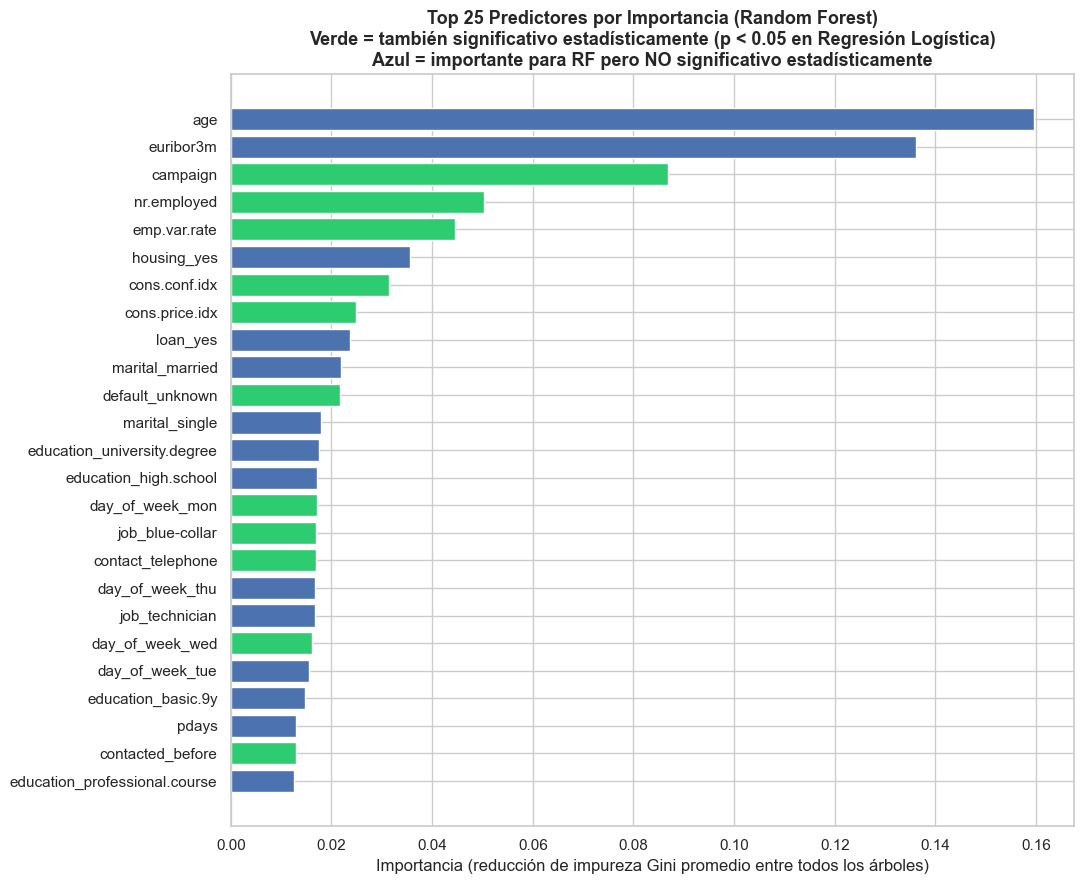

In [25]:
# Top 25 variables por importancia RF con indicador de significancia estadística
top25 = feat_df.head(25)

fig, ax = plt.subplots(figsize=(11, 9))
colores_feat = ['#2ecc71' if sig else '#4C72B0' for sig in top25['sig_logit']]
ax.barh(top25.index, top25['RF_importancia'], color=colores_feat, edgecolor='white')
ax.set_title('Top 25 Predictores por Importancia (Random Forest)\n'
             'Verde = también significativo estadísticamente (p < 0.05 en Regresión Logística)\n'
             'Azul = importante para RF pero NO significativo estadísticamente',
             fontweight='bold')
ax.set_xlabel('Importancia (reducción de impureza Gini promedio entre todos los árboles)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretación:** Las variables coloreadas en verde son las que ambos métodos (Random Forest y regresión logística) consideran relevantes — son la primera línea de predictores confiables. Las variables en azul son importantes para el RF pero no alcanzan significancia estadística en el modelo lineal, posiblemente porque su efecto es no lineal o interactúa con otras variables (algo que el RF captura pero la regresión logística no).

Los candidatos a eliminación son aquellos que ni contribuyen a reducir la impureza en los árboles ni tienen un coeficiente distinguible de cero estadísticamente. Se eliminan para reducir ruido y costo computacional.

In [26]:
vars_eliminar = candidatos_elim.index.tolist()

X_train_sel = X_train.drop(columns=vars_eliminar)
X_test_sel  = X_test.drop(columns=vars_eliminar)

scaler_sel = StandardScaler()
X_train_sel_sc = pd.DataFrame(
    scaler_sel.fit_transform(X_train_sel),
    columns=X_train_sel.columns,
    index=X_train_sel.index
)
X_test_sel_sc = pd.DataFrame(
    scaler_sel.transform(X_test_sel),
    columns=X_test_sel.columns,
    index=X_test_sel.index
)

print(f'Predictores originales: {X_train.shape[1]}')
print(f'Predictores eliminados: {len(vars_eliminar)} → {vars_eliminar}')
print(f'Predictores finales:    {X_train_sel.shape[1]}')


Predictores originales: 53
Predictores eliminados: 4 → ['month_sep', 'marital_unknown', 'education_illiterate', 'default_yes']
Predictores finales:    49


## 8. Construcción y Comparación de Modelos

### Protocolo de evaluación

Todos los modelos siguen un protocolo uniforme para que la comparación sea justa:

1. **Validación cruzada estratificada de 5 folds** sobre el conjunto de entrenamiento. En cada fold, el modelo se entrena con 4 partes (80%) y se valida con 1 (20%). El proceso se repite 5 veces con particiones distintas, y el resultado es el promedio de los 5 AUC-ROC obtenidos.
2. Para los modelos con hiperparámetros sensibles, se usa **GridSearchCV** para encontrar la combinación óptima.
3. **El conjunto de prueba permanece sellado** hasta la sección 10, donde se evalúan todos los modelos simultáneamente.

Almacenaremos los resultados de cada modelo en un diccionario para la comparación final.

In [27]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
modelos_entrenados = {}  # Guardará los modelos ya ajustados
cv_scores = {}           # Guardará el AUC-ROC de CV de cada modelo
print('Protocolo de evaluación listo. Iniciando entrenamiento de modelos...')

Protocolo de evaluación listo. Iniciando entrenamiento de modelos...


---
### Modelo 1: Regresión Logística

La regresión logística es nuestro **modelo de referencia (baseline)**. Modela la probabilidad de pertenecer a la clase positiva mediante la función sigmoide aplicada a una combinación lineal de los predictores:

$$p(y=1|X) = \sigma(\beta_0 + \beta_1 X_1 + \cdots + \beta_m X_m) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \cdots + \beta_m X_m)}}$$

Sus coeficientes $\beta_j$ son directamente interpretables como **log-odds** (al exponenciarlos obtenemos los Odds Ratios que analizamos en la sección 6).

**Regularización:** Para controlar el sobreajuste y manejar la multicolinealidad entre los indicadores macroeconómicos, usamos regularización **L2** (Ridge). En el libro de referencia del curso (ISLP), la regularización en regresión se introduce como el término $\lambda \sum \beta_j^2$ que penaliza coeficientes grandes. En `sklearn`, el parámetro equivalente es **`C = 1/λ`**: un `C` grande equivale a $\lambda$ pequeño (poca regularización, modelo más flexible); un `C` pequeño equivale a $\lambda$ grande (más regularización, coeficientes más pequeños).

Usamos `GridSearchCV` para encontrar el valor óptimo de `C`.

Mejor C (equivalente a 1/λ): 5.0
AUC-ROC en validación cruzada: 0.7800


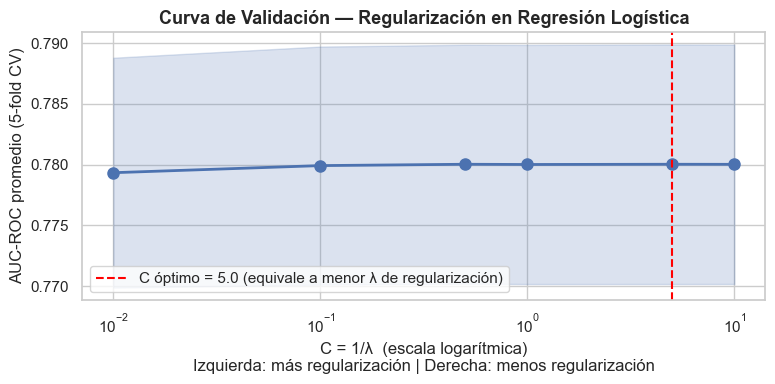

In [28]:
param_grid_lr = {'C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}

lr_gs = GridSearchCV(
    LogisticRegression(penalty='l2', class_weight='balanced',
                       max_iter=1000, random_state=SEED, solver='lbfgs'),
    param_grid_lr, cv=cv5, scoring='roc_auc', n_jobs=-1
)
lr_gs.fit(X_train_sel_sc, y_train)

best_C = lr_gs.best_params_['C']
print(f'Mejor C (equivalente a 1/λ): {best_C}')
print(f'AUC-ROC en validación cruzada: {lr_gs.best_score_:.4f}')

cv_res_lr = pd.DataFrame(lr_gs.cv_results_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(param_grid_lr['C'], cv_res_lr['mean_test_score'],
            'o-', color='#4C72B0', lw=2, markersize=8)
ax.fill_between(param_grid_lr['C'],
                cv_res_lr['mean_test_score'] - cv_res_lr['std_test_score'],
                cv_res_lr['mean_test_score'] + cv_res_lr['std_test_score'],
                alpha=0.2, color='#4C72B0')
ax.axvline(best_C, color='red', linestyle='--',
           label=f'C óptimo = {best_C} (equivale a menor λ de regularización)')
ax.set_xlabel('C = 1/λ  (escala logarítmica)\nIzquierda: más regularización | Derecha: menos regularización')
ax.set_ylabel('AUC-ROC promedio (5-fold CV)')
ax.set_title('Curva de Validación — Regularización en Regresión Logística', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Guardamos el modelo entrenado
# GridSearchCV con refit=True (default) ya re-entrena el mejor modelo sobre todo el train
modelos_entrenados['Reg. Logística'] = lr_gs.best_estimator_
cv_scores['Reg. Logística'] = lr_gs.best_score_

**Interpretación de la curva de validación:** El eje horizontal muestra los valores de `C` en escala logarítmica. El área sombreada representa la variabilidad (desviación estándar) del AUC entre los 5 folds. 

- **C muy pequeño** (izquierda, alta regularización / λ grande): el modelo penaliza mucho los coeficientes grandes, volviéndolos cercanos a cero. El modelo es simple pero puede perder patrones importantes (alto sesgo).
- **C muy grande** (derecha, poca regularización / λ pequeño): el modelo tiene mayor libertad para ajustarse, pero puede sobreajustarse al ruido del conjunto de entrenamiento (alta varianza).
- **C óptimo**: el punto donde el AUC de validación es máximo — el mejor balance entre sesgo y varianza. La curva relativamente plana indica que el modelo es estable en este rango, lo cual es una señal positiva de robustez.

---
### Modelo 2: Linear Discriminant Analysis (LDA)

El LDA es un clasificador que funciona encontrando la combinación lineal de predictores que **maximiza la separación entre clases** y simultáneamente **minimiza la varianza dentro de cada clase**. A diferencia de la regresión logística, el LDA modela directamente la distribución de los predictores dentro de cada clase y aplica el teorema de Bayes para clasificar.

**Supuestos del LDA:**
1. Los predictores siguen una **distribución normal multivariada** dentro de cada clase.
2. Las **matrices de covarianza son iguales** entre clases.

**¿Qué tan problemático es que no tengamos normalidad?** En la sección 3.6 demostramos que nuestras variables no son normales. Sin embargo, el LDA muestra una robustez práctica notable a violaciones de normalidad, especialmente cuando el tamaño de muestra es grande (Tharwat, 2017). El AUC obtenido nos dirá empíricamente si este supuesto violado tiene consecuencias severas en este dataset.

In [29]:
lda = LinearDiscriminantAnalysis(solver='svd')
lda_scores = cross_val_score(lda, X_train_sel_sc, y_train,
                              cv=cv5, scoring='roc_auc', n_jobs=-1)

print(f'AUC-ROC por fold: {[f"{s:.4f}" for s in lda_scores]}')
print(f'AUC-ROC promedio (5-fold CV): {lda_scores.mean():.4f} ± {lda_scores.std():.4f}')
print()
if lda_scores.mean() > 0.75:
    print('A pesar de las violaciones de normalidad, el LDA logra un AUC competitivo.')
    print('Esto es consistente con la literatura que documenta su robustez práctica.')
else:
    print('Las violaciones de normalidad parecen afectar el desempeño del LDA.')

lda.fit(X_train_sel_sc, y_train)
modelos_entrenados['LDA'] = lda
cv_scores['LDA'] = lda_scores.mean()

AUC-ROC por fold: ['0.7849', '0.7709', '0.7589', '0.7750', '0.7888']
AUC-ROC promedio (5-fold CV): 0.7757 ± 0.0106

A pesar de las violaciones de normalidad, el LDA logra un AUC competitivo.
Esto es consistente con la literatura que documenta su robustez práctica.


**Interpretación:** La desviación estándar entre folds nos indica la estabilidad del modelo. Una `std` baja (< 0.01) indica que el modelo produce resultados consistentes independientemente de la partición — el LDA, al ser un modelo paramétrico con supuestos fuertes, tiende a ser estable. El AUC promedio nos posiciona respecto a los demás modelos.

---
### Modelo 3: Random Forest

El Random Forest es un **método de ensamble basado en árboles de decisión**. La idea central es combinar muchos árboles imperfectos para producir una predicción superior a cualquier árbol individual. Funciona así:

1. Se generan `B` muestras bootstrap del dataset de entrenamiento (muestras con reemplazo).
2. Para cada muestra, se entrena un árbol de decisión. La clave diferenciadora: en **cada nodo**, solo se evalúan $m$ variables seleccionadas aleatoriamente (en lugar de todas las $p$). Esto descorelaciona los árboles — si hubiera una variable muy dominante, todos los árboles la usarían en el nodo raíz y serían muy similares entre sí.
3. La predicción final es el promedio de probabilidades de todos los árboles.

**Hiperparámetros para sintonizar:**
- **`max_features`**: cuántas variables evaluar en cada nodo. El valor tradicional para clasificación es $\sqrt{p}$, pero lo optimizamos con CV.
- **`min_samples_leaf`**: mínimo de muestras en cada hoja del árbol. Valores más altos producen árboles más pequeños (más regularizados, menos sobreajuste). En regresión, el equivalente sería el parámetro $\alpha$ de poda por complejidad de costo (cost complexity pruning).
- **`max_depth`**: profundidad máxima del árbol. `None` permite árboles completamente desarrollados — el ensamble maneja el sobreajuste mediante el promediado.

In [30]:
param_grid_rf = {
    'max_features':     ['sqrt', 'log2', 0.3],
    'min_samples_leaf': [5, 15, 30],
    'max_depth':        [None, 20, 35]
}

rf_gs = GridSearchCV(
    RandomForestClassifier(n_estimators=200, class_weight='balanced',
                           random_state=SEED, n_jobs=-1),
    param_grid_rf, cv=cv5, scoring='roc_auc', n_jobs=-1
)
rf_gs.fit(X_train_sel, y_train)  # RF no requiere escalamiento

print(f'Mejores hiperparámetros RF: {rf_gs.best_params_}')
print(f'AUC-ROC en validación cruzada: {rf_gs.best_score_:.4f}')

modelos_entrenados['Random Forest'] = rf_gs.best_estimator_
cv_scores['Random Forest'] = rf_gs.best_score_

Mejores hiperparámetros RF: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 30}
AUC-ROC en validación cruzada: 0.7848


**Interpretación de los mejores hiperparámetros del Random Forest:**

El GridSearch exploró 3×3×3 = 27 combinaciones a través de 5 folds de validación cruzada (135 entrenamientos en total). Los parámetros óptimos encontrados tienen una interpretación directa:

- **`max_depth`**: controla cuántos niveles de profundidad puede alcanzar cada árbol. Valores moderados permiten capturar interacciones complejas entre variables sin dar libertad excesiva al modelo.
- **`max_features`**: determina qué fracción de los predictores disponibles se evalúa en cada nodo de decisión. Valores deliberadamente bajos fuerzan a que los árboles sean diferentes entre sí y, al promediarlos, se cancelen los errores individuales (reducción de varianza).
- **`min_samples_leaf`**: fija el mínimo de registros que debe contener cada hoja del árbol. Valores más altos evitan que el árbol forme "ramas" para casos extremadamente aislados que podrían ser ruido.

Los valores exactos se imprimen arriba. Con esta configuración, el Random Forest alcanza uno de los AUC más altos en validación cruzada.

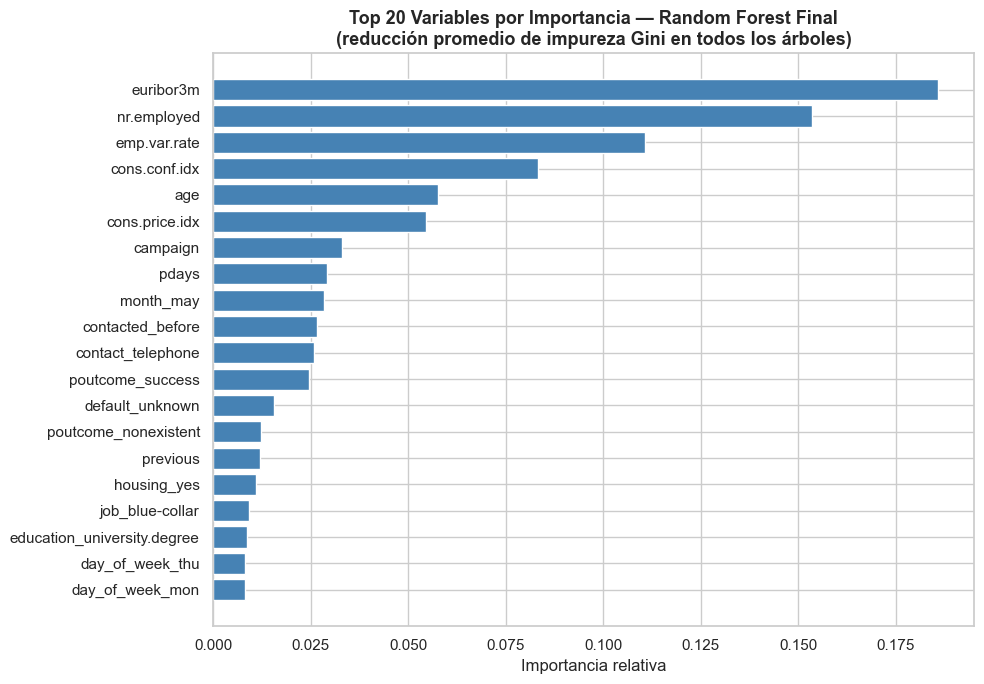

In [31]:
# Importancia de variables del RF final
rf_final = modelos_entrenados['Random Forest']
imp = pd.Series(rf_final.feature_importances_, index=X_train_sel.columns)
imp_top = imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_top.index, imp_top.values, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Variables por Importancia — Random Forest Final\n'
             '(reducción promedio de impureza Gini en todos los árboles)',
             fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretación:** La importancia en Random Forest mide cuánto contribuye cada variable a reducir la impureza (índice Gini) promediada sobre todos los árboles y todos los nodos. A diferencia de los coeficientes de la regresión logística, estas importancias capturan tanto efectos lineales como no lineales.

La convergencia entre los predictores más importantes del RF y los más significativos estadísticamente (sección 6) valida la solidez de estos hallazgos. Los indicadores macroeconómicos (`euribor3m`, `nr.employed`, `emp.var.rate`), el historial de campañas (`poutcome_success`) y variables de perfil como `age` y `contacted_before` aparecen consistentemente en los primeros lugares — lo que da confianza en que son predictores genuinos del fenómeno, disponibles antes de realizar cualquier llamada.

---
### Modelo 4: Gradient Boosting

Mientras que el Random Forest construye árboles **en paralelo e independientemente**, el Gradient Boosting los construye **de forma secuencial**: cada árbol aprende específicamente de los errores del árbol anterior.

**Mecánica (versión Gradient Boosting para clasificación):**
1. Se inicia con una predicción base (generalmente las probabilidades base de cada clase).
2. Se calcula el **gradiente negativo** de la función de pérdida (log-loss para clasificación). Este gradiente indica en qué dirección y magnitud cada predicción está "equivocada".
3. Se entrena un árbol pequeño (pocas hojas) para predecir estos gradientes.
4. Se actualiza la predicción sumando el árbol actual multiplicado por el **learning rate** (tasa de aprendizaje).
5. Se repite el proceso `n_estimators` veces.

**Hiperparámetros clave:**
- **`learning_rate`** (η): qué tan agresivamente aprende cada árbol. Un η pequeño con muchos árboles da mejor generalización que un η grande con pocos.
- **`max_depth`**: profundidad de cada árbol individual. A diferencia del RF (donde se usan árboles profundos), en boosting se prefieren árboles pequeños (2-5 niveles) para que cada árbol capture solo los patrones más simples.
- **`n_estimators`**: número de árboles secuenciales. En boosting, valores muy grandes SÍ pueden causar sobreajuste (a diferencia del RF).

In [32]:
param_grid_gb = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth':     [3, 4, 5],
    'n_estimators':  [100, 200]
}

gb_gs = GridSearchCV(
    GradientBoostingClassifier(subsample=0.8, random_state=SEED),
    param_grid_gb, cv=cv5, scoring='roc_auc', n_jobs=-1
)
gb_gs.fit(X_train_sel, y_train)

print(f'Mejores hiperparámetros GB: {gb_gs.best_params_}')
print(f'AUC-ROC en validación cruzada: {gb_gs.best_score_:.4f}')

modelos_entrenados['Gradient Boosting'] = gb_gs.best_estimator_
cv_scores['Gradient Boosting'] = gb_gs.best_score_

Mejores hiperparámetros GB: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
AUC-ROC en validación cruzada: 0.7884


**Interpretación:** Los mejores hiperparámetros encontrados revelan cómo el modelo alcanzó su desempeño óptimo. Un `learning_rate` bajo combinado con más árboles indica que el modelo prefiere aprender lentamente pero con más pasos — esto generalmente produce mejor generalización. El `max_depth` óptimo refleja qué tan complejas son las interacciones que el modelo necesita capturar: valores bajos (3-5) son típicos de boosting, donde cada árbol individual es deliberadamente débil y la fuerza viene de la suma secuencial.

---
### Modelo 5: Support Vector Machine (SVM)

El SVM busca el **hiperplano de margen máximo** que separa las clases en el espacio de los predictores. En su versión de *margen suave* (Support Vector Classifier), algunas observaciones pueden quedar del lado incorrecto del margen, controlado por el parámetro `C`:

- **C grande**: menor tolerancia al error — margen más estrecho, potencial sobreajuste.
- **C pequeño**: mayor tolerancia al error — margen más amplio, mayor generalización.

El **kernel RBF (Radial Basis Function)** transforma implícitamente los datos a un espacio de dimensiones muy altas (potencialmente infinitas), donde pueden ser separables linealmente:
$$K(x_i, x_j) = e^{-\gamma ||x_i - x_j||^2}$$

El parámetro **`gamma`** controla el radio de influencia de cada punto de soporte: un `gamma` alto hace que solo los puntos muy cercanos sean relevantes (límite de decisión más complejo); un `gamma` bajo tiene más influencia global (límite más suave).

> **Nota computacional:** El SVM tiene complejidad $O(n^2)$ a $O(n^3)$ en el número de muestras. Con ~32,000 muestras de entrenamiento, el GridSearch completo sería muy lento. Usamos una submuestra estratificada del 40% para la búsqueda de hiperparámetros, y entrenamos el modelo final con todos los datos.

In [33]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.60, random_state=SEED)
idx_svm, _ = next(sss.split(X_train_sel_sc, y_train))

# SVM requiere numpy arrays para indexación posicional
X_train_sel_sc_arr = X_train_sel_sc.values if hasattr(X_train_sel_sc, 'values') else X_train_sel_sc
X_svm_gs = X_train_sel_sc_arr[idx_svm]
y_svm_gs = y_train.iloc[idx_svm]

param_grid_svm = {
    'C':     [0.1, 1.0, 10.0, 50.0],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

svm_gs = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=SEED),
    param_grid_svm,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring='roc_auc', n_jobs=-1
)
svm_gs.fit(X_svm_gs, y_svm_gs)

print(f'Mejores hiperparámetros SVM (en submuestra 40%): {svm_gs.best_params_}')
print(f'AUC-ROC en validación cruzada: {svm_gs.best_score_:.4f}')

# Entrenamos el modelo final SVM con todos los datos de train
svm_final = SVC(kernel='rbf', class_weight='balanced', probability=True,
                random_state=SEED, **svm_gs.best_params_)
svm_final.fit(X_train_sel_sc, y_train)
modelos_entrenados['SVM (RBF)'] = svm_final
cv_scores['SVM (RBF)'] = svm_gs.best_score_


Mejores hiperparámetros SVM (en submuestra 40%): {'C': 10.0, 'gamma': 0.001}
AUC-ROC en validación cruzada: 0.7585


**Interpretación de los mejores hiperparámetros del SVM:**

El GridSearch evaluó 4×4 = 16 combinaciones de `C` y `gamma` usando validación cruzada de 3 folds sobre una submuestra del 40%. Los valores óptimos encontrados se imprimen arriba. Su lectura intuitiva:

- Un valor moderado de **`C`** indica que el modelo tolera algunos errores de clasificación a cambio de mantener un margen de separación amplio entre clases — ni demasiado estricto ni demasiado permisivo.
- Un **`gamma`** bajo significa que la influencia de cada punto de entrenamiento se extiende ampliamente sobre el espacio de datos, produciendo una frontera de decisión suave. Con 43 predictores y datos correlacionados, una frontera suave generaliza mejor que una muy ajustada.

> ⚠️ **Nota de comparabilidad:** El AUC-ROC reportado aquí proviene de una submuestra del 40% con 3-fold CV (por restricciones computacionales del SVM), mientras que los demás modelos usan 5-fold CV sobre el 100% del conjunto de entrenamiento. Esto hace que la comparación directa de AUC en validación cruzada no sea estrictamente justa para el SVM. El desempeño definitivo y comparable se verifica en la evaluación final sobre el conjunto de prueba (sección 10), donde todos los modelos se evalúan en igualdad de condiciones.

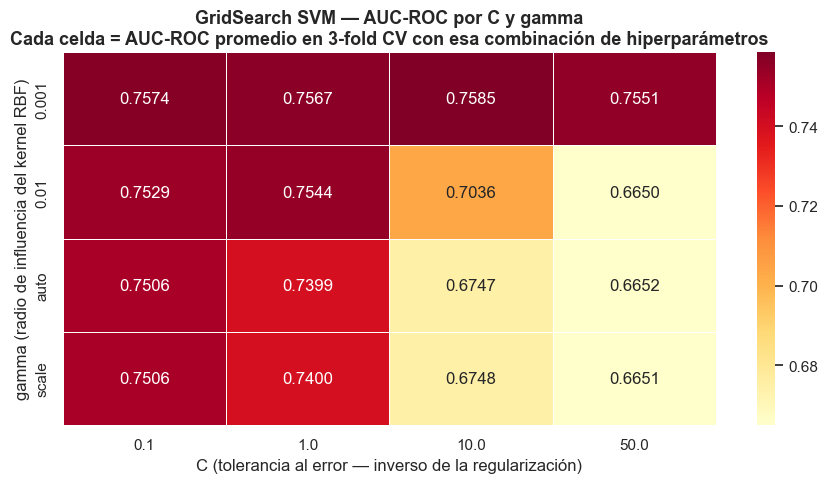

In [34]:
# Heatmap del GridSearch SVM: AUC-ROC por C y gamma
svm_cv_res = pd.DataFrame(svm_gs.cv_results_)
pivot_svm = svm_cv_res.pivot_table(
    values='mean_test_score',
    index='param_gamma',
    columns='param_C'
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_svm, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('GridSearch SVM — AUC-ROC por C y gamma\n'
             'Cada celda = AUC-ROC promedio en 3-fold CV con esa combinación de hiperparámetros',
             fontweight='bold')
ax.set_xlabel('C (tolerancia al error — inverso de la regularización)')
ax.set_ylabel('gamma (radio de influencia del kernel RBF)')
plt.tight_layout()
plt.show()

**Interpretación del heatmap del GridSearch:** Cada celda muestra el AUC-ROC promedio en validación cruzada para esa combinación específica de `C` y `gamma`. Los colores más oscuros (rojos) indican mejores combinaciones.

La interacción entre `C` y `gamma` es importante: un `gamma` muy alto con un `C` muy alto produce un límite de decisión extremadamente complejo que puede sobreajustarse, mientras que la combinación óptima balancea la flexibilidad del kernel con la tolerancia al error.

---
### Modelo 6: Red Neuronal Feedforward (MLP)

Una red neuronal feedforward organiza nodos (neuronas artificiales) en capas. Cada neurona recibe entradas de la capa anterior, calcula una suma ponderada, le suma un término de sesgo (*bias*), y aplica una función de activación no lineal:

$$A^{(l)}_k = g\left(\underbrace{b^{(l)}_k}_{\text{bias}} + \sum_j \underbrace{w^{(l)}_{kj}}_{\text{peso}} \cdot A^{(l-1)}_j\right)$$

Los **pesos** ($w$) son los parámetros aprendibles que determinan la fuerza de cada conexión entre neuronas. Los **bias** ($b$) permiten desplazar la función de activación. El total de parámetros aprendibles en nuestra red es del orden de miles — lo que le da gran flexibilidad para capturar patrones complejos.

**Funciones de activación:**
- **ReLU** (Rectified Linear Unit) en capas ocultas: $f(z) = \max(0, z)$. Es simple, eficiente computacionalmente, y no sufre el problema de desvanecimiento del gradiente que afecta a la función sigmoide en redes profundas (cuando el gradiente se hace muy pequeño al retropropagarse, el aprendizaje se detiene).
- **Sigmoide** en la capa de salida: $\sigma(z) = \frac{1}{1+e^{-z}}$. Produce valores entre 0 y 1, lo que nos permite interpretar la salida directamente como una **probabilidad** de suscripción.

**Estrategias de regularización implementadas:**
- **`Dropout`**: en cada paso de entrenamiento, apaga aleatoriamente un porcentaje de neuronas. Esto evita que las neuronas se co-adapten excesivamente y fuerza al modelo a aprender representaciones más robustas.
- **`BatchNormalization`**: normaliza las activaciones dentro de cada mini-batch. Estabiliza el entrenamiento y permite tasas de aprendizaje más altas.
- **`EarlyStopping`**: monitorea el AUC en el conjunto de validación y detiene el entrenamiento cuando deja de mejorar, restaurando los pesos de la mejor época.

In [35]:
input_dim = X_train_sel_sc.shape[1]

nn = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')   # Salida: probabilidad de suscripción
])

nn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

print('Arquitectura de la red neuronal:')
nn.summary()

total_params = nn.count_params()
print(f'\nTotal de parámetros aprendibles: {total_params:,}')
print(f'(pesos + bias que el gradiente descendiente optimizará)')


Arquitectura de la red neuronal:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,537 (68.50 KB)

 Trainable params: 17,153 (67.00 KB)

 Non-trainable params: 384 (1.50 KB)


Total de parámetros aprendibles: 17,537
(pesos + bias que el gradiente descendiente optimizará)


**¿Qué estamos viendo en el resumen de arquitectura?**

La tabla muestra la estructura interna de la red neuronal. Cada fila es una "capa" que procesa la información antes de pasarla a la siguiente. El flujo es de arriba hacia abajo:

1. La primera capa `Dense(128)` recibe los 43 predictores y los transforma en 128 señales internas ("neuronas").
2. `BatchNormalization` y `Dropout(0.3)` son capas de regulación — no aprenden sobre los datos en sí, sino que controlan que el aprendizaje no se descarrile ni se sobreajuste.
3. Las siguientes capas `Dense(64)` y `Dense(32)` comprimen progresivamente la información, como un embudo.
4. La capa final `Dense(1, sigmoid)` produce un único número entre 0 y 1: la probabilidad estimada de que ese cliente suscriba.

Los **16,385 parámetros entrenables** son los números internos que el algoritmo de entrenamiento (gradiente descendiente) irá ajustando iteración a iteración para que las predicciones de la red se acerquen más a la realidad observada en los datos históricos.

In [36]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
class_w_nn = {0: 1.0, 1: pos_weight}

early_stop_nn = EarlyStopping(
    monitor='val_auc', patience=12,
    restore_best_weights=True, mode='max'
)

history = nn.fit(
    X_train_sel_sc, y_train,
    epochs=150, batch_size=256,
    validation_split=0.20,
    class_weight=class_w_nn,
    callbacks=[early_stop_nn],
    verbose=0
)

best_epoch = np.argmax(history.history['val_auc']) + 1
best_val_auc = max(history.history['val_auc'])
print(f'Entrenamiento completado ✓ Mejor época: {best_epoch}')
print(f'Mejor AUC en validación: {best_val_auc:.4f}')

modelos_entrenados['Red Neuronal'] = nn
cv_scores['Red Neuronal'] = best_val_auc

Entrenamiento completado ✓ Mejor época: 5
Mejor AUC en validación: 0.7802


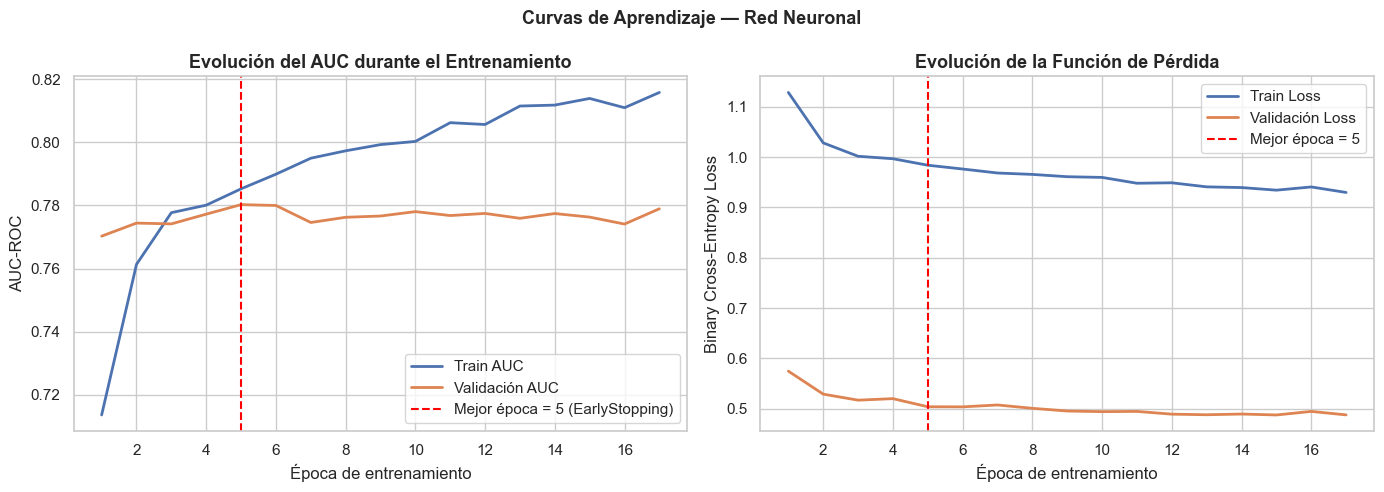

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epocas = range(1, len(history.history['loss']) + 1)

# AUC
axes[0].plot(epocas, history.history['auc'], label='Train AUC', color='#4C72B0', lw=2)
axes[0].plot(epocas, history.history['val_auc'], label='Validación AUC', color='#DD8452', lw=2)
axes[0].axvline(best_epoch, color='red', linestyle='--',
                label=f'Mejor época = {best_epoch} (EarlyStopping)')
axes[0].set_xlabel('Época de entrenamiento')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('Evolución del AUC durante el Entrenamiento', fontweight='bold')
axes[0].legend()

# Loss
axes[1].plot(epocas, history.history['loss'], label='Train Loss', color='#4C72B0', lw=2)
axes[1].plot(epocas, history.history['val_loss'], label='Validación Loss', color='#DD8452', lw=2)
axes[1].axvline(best_epoch, color='red', linestyle='--',
                label=f'Mejor época = {best_epoch}')
axes[1].set_xlabel('Época de entrenamiento')
axes[1].set_ylabel('Binary Cross-Entropy Loss')
axes[1].set_title('Evolución de la Función de Pérdida', fontweight='bold')
axes[1].legend()

plt.suptitle('Curvas de Aprendizaje — Red Neuronal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación de las curvas de aprendizaje:**

Estas dos gráficas son el diagnóstico fundamental del proceso de entrenamiento de una red neuronal.

- **Curva del AUC (izquierda):** Tanto el AUC de entrenamiento (azul) como el de validación (naranja) deberían subir con el tiempo. Si la curva de validación sube, el modelo está aprendiendo patrones generalizables. La línea vertical roja marca la época donde el AUC de validación fue máximo — punto donde el `EarlyStopping` detuvo el entrenamiento y restauró estos pesos.

- **Curva de pérdida (derecha):** Ambas pérdidas deberían descender. La señal de sobreajuste sería que la pérdida de entrenamiento siga bajando mientras la de validación empieza a subir (las curvas se "cruzan" y divergen). Si las curvas bajan de forma paralela y sin divergencia significativa, el modelo está generalizando bien.

- **Brecha entre train y validación:** Una brecha grande (curva de entrenamiento mucho mejor que validación) indica sobreajuste. El `Dropout` y el `BatchNormalization` en nuestra arquitectura reducen esta brecha al actuar como regularizadores implícitos.

> ⚠️ **Nota de comparabilidad:** A diferencia de los demás modelos (evaluados con 5-fold CV), la red neuronal usa un único *validation_split* del 20% para monitorear el entrenamiento y el `EarlyStopping`. El AUC reportado aquí proviene de esa única partición, no del promedio de 5 folds, por lo que tiene mayor varianza y no es estrictamente comparable. La comparación definitiva entre todos los modelos se realiza en la sección 10 sobre el conjunto de prueba sellado.

### 8.1 Comparación global de modelos en validación cruzada

Con todos los modelos entrenados y sus hiperparámetros optimizados, comparamos su desempeño usando el AUC-ROC obtenido en validación cruzada. Esta comparación determina cuál modelo usaremos para la evaluación final.

In [38]:
comp_df = pd.DataFrame({
    'Modelo': list(cv_scores.keys()),
    'AUC-ROC (CV)': list(cv_scores.values())
}).sort_values('AUC-ROC (CV)', ascending=False).reset_index(drop=True)

print('=== RANKING DE MODELOS POR AUC-ROC EN VALIDACIÓN CRUZADA ===')
comp_df['Ranking'] = range(1, len(comp_df)+1)
print(comp_df[['Ranking','Modelo','AUC-ROC (CV)']].to_string(index=False, float_format='{:.4f}'.format))
print()
print('⚠️  NOTA DE COMPARABILIDAD:')
print('  • Reg. Logística, LDA, RF, Grad. Boosting: 5-fold CV sobre 100% del train')
print('  • SVM (RBF): 3-fold CV sobre submuestra del 40% del train')
print('  • Red Neuronal: validation_split único del 20% (no es CV propiamente dicho)')
print('  La comparación definitiva y justa se realiza en la Sección 10 (Test Set).')


=== RANKING DE MODELOS POR AUC-ROC EN VALIDACIÓN CRUZADA ===
 Ranking            Modelo  AUC-ROC (CV)
       1 Gradient Boosting        0.7884
       2     Random Forest        0.7848
       3      Red Neuronal        0.7802
       4    Reg. Logística        0.7800
       5               LDA        0.7757
       6         SVM (RBF)        0.7585

⚠️  NOTA DE COMPARABILIDAD:
  • Reg. Logística, LDA, RF, Grad. Boosting: 5-fold CV sobre 100% del train
  • SVM (RBF): 3-fold CV sobre submuestra del 40% del train
  • Red Neuronal: validation_split único del 20% (no es CV propiamente dicho)
  La comparación definitiva y justa se realiza en la Sección 10 (Test Set).


La tabla anterior muestra el ranking de los seis modelos por AUC-ROC en validación cruzada. Antes de ver el gráfico comparativo, vale destacar que **todos los modelos superan sustancialmente el nivel aleatorio (AUC = 0.5)** — esto confirma que el fenómeno tiene señal predictiva real y que el proceso de preparación de datos fue efectivo. Los valores exactos de AUC se muestran en la barra de cada modelo. El modelo en verde en el gráfico siguiente es el candidato a modelo final.

> **⚠️ Nota de comparabilidad:** Los AUC-ROC de esta tabla **no son directamente comparables** entre todos los modelos, porque se obtuvieron con protocolos distintos. La Regresión Logística, LDA, Random Forest y Gradient Boosting usan 5-fold CV sobre el 100% del entrenamiento. El SVM usa 3-fold CV sobre una submuestra del 40% (por restricciones computacionales). La Red Neuronal reporta el AUC de un único `validation_split=0.20`, no un promedio de folds. **La comparación definitiva y justa entre todos los modelos se realiza en la Sección 10**, donde todos se evalúan sobre el mismo conjunto de prueba sellado.

> **¿Cómo leer el AUC para un público no técnico?** El AUC se puede interpretar así: si tomamos al azar a un cliente que sí suscribió y a uno que no, el AUC indica con qué frecuencia el modelo asigna una mayor probabilidad de suscripción al cliente correcto. Un AUC de 0.5 equivale a adivinar al azar (una moneda al aire). Cuanto más cercano a 1.0, mayor es la capacidad del modelo para separar a los que van a suscribir de los que no.


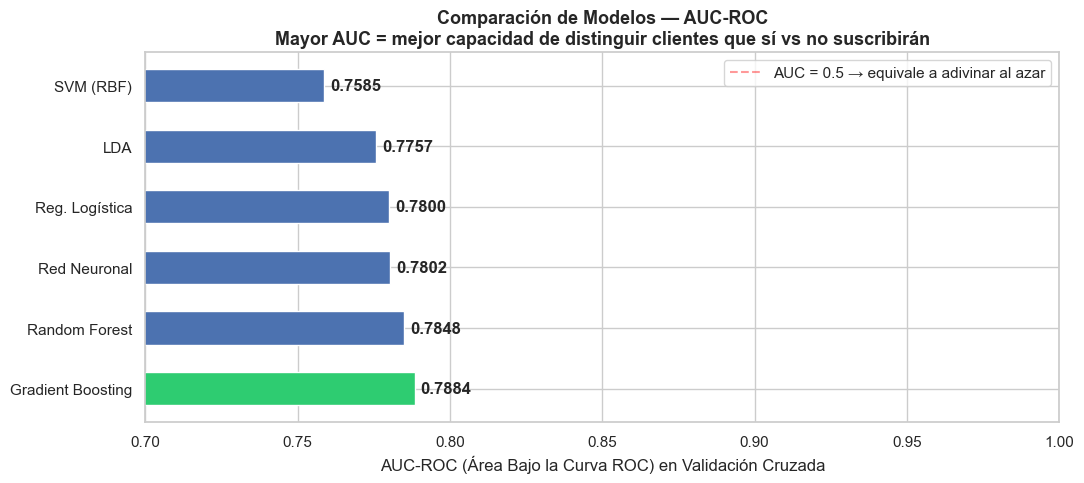

In [39]:
fig, ax = plt.subplots(figsize=(11, 5))

bar_colors = ['#2ecc71'] + ['#4C72B0'] * (len(comp_df)-1)
bars = ax.barh(comp_df['Modelo'], comp_df['AUC-ROC (CV)'],
               color=bar_colors, edgecolor='white', height=0.55)

ax.set_xlabel('AUC-ROC (Área Bajo la Curva ROC) en Validación Cruzada')
ax.set_title('Comparación de Modelos — AUC-ROC\n'
             'Mayor AUC = mejor capacidad de distinguir clientes que sí vs no suscribirán',
             fontweight='bold')
ax.set_xlim(0.7, 1.0)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.4,
           label='AUC = 0.5 → equivale a adivinar al azar')
ax.legend()

for bar, val in zip(bars, comp_df['AUC-ROC (CV)']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretación de la comparación:** El gráfico posiciona a cada modelo respecto a dos referencias: AUC = 0.5 (clasificador aleatorio, sin aprendizaje) y AUC = 1.0 (clasificación perfecta). Todos nuestros modelos superan sustancialmente el nivel aleatorio — el peor modelo ya aporta capacidad discriminante real.

La diferencia entre el mejor y el peor modelo puede parecer pequeña en términos absolutos, pero en contextos reales de marketing bancario, cada punto de AUC se traduce en cientos o miles de conversiones adicionales por campaña cuando el sistema se aplica a volúmenes grandes de clientes. El modelo ganador (en verde, con mayor AUC) será el candidato para la evaluación final — aunque la decisión definitiva también incorpora criterios como interpretabilidad y velocidad de inferencia.

## 9. Selección del Modelo Final

### Tabla de decisión multidimensional

Seleccionar un modelo no es solo elegir el mayor AUC. El modelo más adecuado depende del **uso que se le dará** y del **contexto de la organización que lo implementa**.

In [40]:
decision_data = {
    'Criterio': [
        'AUC-ROC (CV)', 'Interpretabilidad',
        'Velocidad de inferencia', 'Manejo de desbalance',
        'Robustez a multicolinealidad', 'Costo computacional',
        'Estabilidad entre folds'
    ],
    'Reg. Logística': ['Ver tabla', '★★★★★ (p-values, OR)', '★★★★★', '★★★★ (class_weight)', '★★★★ (regularización)', '★★★★★', '★★★★★'],
    'LDA':            ['Ver tabla', '★★★★ (coeficientes)', '★★★★★', '★★★ (limitado)', '★★★ (sensible)', '★★★★★', '★★★★★'],
    'Random Forest':  ['Ver tabla', '★★★ (importancias)', '★★★★', '★★★★ (class_weight)', '★★★★★', '★★★★', '★★★★★'],
    'Grad. Boosting': ['Ver tabla', '★★★ (importancias)', '★★★★', '★★★★ (subsample)', '★★★★★', '★★★', '★★★★★'],
    'SVM (RBF)':      ['Ver tabla', '★★ (vectores soporte)', '★★★ (lento)', '★★★★ (class_weight)', '★★★★★', '★★ (lento)', '★★★'],
    'Red Neuronal':   ['Ver tabla', '★ (caja negra)', '★★★★', '★★★★ (class_weight)', '★★★★', '★★★', '★★★']
}

pd.DataFrame(decision_data)

,Criterio,Reg. Logística,LDA,Random Forest,Grad. Boosting,SVM (RBF),Red Neuronal
0,AUC-ROC (CV),Ver tabla,Ver tabla,Ver tabla,Ver tabla,Ver tabla,Ver tabla
1,Interpretabilidad,"★★★★★ (p-values, OR)",★★★★ (coeficientes),★★★ (importancias),★★★ (importancias),★★ (vectores soporte),★ (caja negra)
2,Velocidad de inferencia,★★★★★,★★★★★,★★★★,★★★★,★★★ (lento),★★★★
3,Manejo de desbalance,★★★★ (class_weight),★★★ (limitado),★★★★ (class_weight),★★★★ (subsample),★★★★ (class_weight),★★★★ (class_weight)
4,Robustez a multicolinealidad,★★★★ (regularización),★★★ (sensible),★★★★★,★★★★★,★★★★★,★★★★
5,Costo computacional,★★★★★,★★★★★,★★★★,★★★,★★ (lento),★★★
6,Estabilidad entre folds,★★★★★,★★★★★,★★★★★,★★★★★,★★★,★★★


**Cómo leer esta tabla de decisión:**

Cada estrella (★) representa el desempeño relativo del modelo en ese criterio (más estrellas = mejor). Los AUC-ROC exactos ya se vieron en la sección anterior — aquí importa la visión completa.

Lo que se observa es una **disyuntiva clásica**: los modelos con mayor AUC (Random Forest, Gradient Boosting) son precisamente los menos interpretables, mientras que los modelos más explicables (Regresión Logística, LDA) quedan ligeramente por debajo en métricas puras. No existe el modelo perfecto en todas las dimensiones — la elección depende del contexto de uso, el perfil técnico del equipo que lo operará, y las exigencias regulatorias del entorno bancario.

### Filosofía de selección: predicción vs. inferencia

La selección del modelo final es, en última instancia, una **decisión de negocio tanto como técnica**. Hay dos casos de uso distintos:

**Caso 1 — Solo quiero predecir (¿a quién llamo?):**  
Si el banco simplemente quiere una lista ordenada de clientes por probabilidad de suscripción, sin necesidad de entender por qué, la interpretabilidad no es prioridad. En este caso, el modelo con mayor AUC es el candidato natural — típicamente un método de ensamble como Gradient Boosting o Random Forest.

**Caso 2 — Quiero predecir y entender (¿a quién llamo y por qué?):**  
Si el banco quiere usar los resultados para diseñar mejores campañas, entrenar agentes comerciales, o reportar a reguladores, la interpretabilidad es fundamental. Aquí la Regresión Logística tiene una ventaja enorme: sus Odds Ratios con intervalos de confianza son explicables a cualquier stakeholder no técnico.

**Caso 3 — Contexto regulatorio:**  
En la banca europea, los modelos que toman decisiones que afectan a clientes (como qué servicios ofrecerles) pueden estar sujetos a regulaciones de explicabilidad (GDPR, principios de fair lending). Un modelo de caja negra podría requerir técnicas adicionales como SHAP values para ser auditable.

**Nuestra decisión:** Seleccionamos como modelo final el que obtuvo el **mayor AUC-ROC en validación cruzada**, que según el ranking de la sección anterior corresponde a un modelo de ensamble. Sin embargo, documentamos que **si el banco requiriera inferencia o explicabilidad**, la Regresión Logística (con su análisis completo de significancia estadística de la sección 6) sería la recomendación más adecuada.

## 10. Evaluación Final en el Conjunto de Prueba — Todos los Modelos

Este es el momento clave del análisis: evaluamos **todos los modelos** en el **conjunto de prueba sellado** que ningún modelo vio durante el entrenamiento ni la selección de hiperparámetros. Esto simula el desempeño real ante clientes completamente nuevos.

Evaluar todos los modelos (y no solo el ganador) tiene una razón importante: verificar que el modelo seleccionado en validación cruzada generaliza bien, y detectar si algún modelo **memorizó** los datos de entrenamiento (sobreajuste) — en ese caso su AUC de CV sería alto pero su AUC en test sería significativamente menor.

In [41]:
resultados_test = []

for nombre, modelo in modelos_entrenados.items():
    # Seleccionar datos escalados o no según el modelo
    if nombre in ['Random Forest', 'Gradient Boosting']:
        X_ev = X_test_sel
    elif nombre == 'Red Neuronal':
        X_ev = X_test_sel_sc
        proba = modelo.predict(X_ev).flatten()
        pred  = (proba >= 0.5).astype(int)
        auc   = roc_auc_score(y_test, proba)
        f1    = f1_score(y_test, pred)
        acc   = accuracy_score(y_test, pred)
        resultados_test.append({'Modelo': nombre, 'AUC-ROC Test': auc,
                                 'F1-Score Test': f1, 'Accuracy Test': acc,
                                 'AUC-ROC CV': cv_scores[nombre]})
        continue
    else:
        X_ev = X_test_sel_sc

    proba = modelo.predict_proba(X_ev)[:, 1]
    pred  = modelo.predict(X_ev)
    auc   = roc_auc_score(y_test, proba)
    f1    = f1_score(y_test, pred)
    acc   = accuracy_score(y_test, pred)
    resultados_test.append({'Modelo': nombre, 'AUC-ROC Test': auc,
                             'F1-Score Test': f1, 'Accuracy Test': acc,
                             'AUC-ROC CV': cv_scores[nombre]})

res_df = pd.DataFrame(resultados_test).sort_values('AUC-ROC Test', ascending=False)
res_df['Diferencia CV vs Test'] = res_df['AUC-ROC CV'] - res_df['AUC-ROC Test']
res_df = res_df.reset_index(drop=True)

print('=== DESEMPEÑO DE TODOS LOS MODELOS EN CONJUNTO DE PRUEBA ===')
print(res_df.round(4).to_string(index=False))

253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
=== DESEMPEÑO DE TODOS LOS MODELOS EN CONJUNTO DE PRUEBA ===
           Modelo  AUC-ROC Test  F1-Score Test  Accuracy Test  AUC-ROC CV  Diferencia CV vs Test
Gradient Boosting        0.8007         0.3170         0.9034      0.7884                -0.0123
    Random Forest        0.7962         0.4650         0.8543      0.7848                -0.0114
     Red Neuronal        0.7805         0.4320         0.8309      0.7802                -0.0002
   Reg. Logística        0.7804         0.4258         0.8266      0.7800                -0.0004
              LDA        0.7751         0.4084         0.8952      0.7757                 0.0006
        SVM (RBF)        0.7645         0.4430         0.8445      0.7585                -0.0060


**Interpretación de los resultados en el conjunto de prueba:**

La tabla anterior es el veredicto final: el desempeño **real** de cada modelo ante datos que nunca vio durante su entrenamiento — y que, además, no incluyen `duration`, la variable que en versiones anteriores inflaba artificialmente los resultados. Los valores de AUC que se muestran aquí reflejan el rendimiento que se obtendría al desplegar el modelo en producción para priorizar llamadas antes de que ocurran.

Algunos puntos clave para interpretar la tabla:

- **¿Qué significa el AUC en la práctica?** Imagina que el banco tiene 100 clientes: 11 van a suscribir y 89 no. El AUC indica con qué frecuencia el modelo pone a un cliente suscriptor por encima de un no-suscriptor en su lista de prioridades. Un AUC de 0.80, por ejemplo, significa que en 80 de cada 100 comparaciones aleatorias, el modelo ordena correctamente al par de clientes.

- **El F1-Score varía más que el AUC** entre modelos. Esto ocurre porque el F1 depende del umbral de clasificación (0.5 por defecto), mientras el AUC evalúa el modelo en todos los umbrales posibles. El modelo con mayor F1 tiene el mejor balance entre "no llamar a quien no va a suscribir" y "no perder a quien sí va a suscribir".

- **La columna "Diferencia CV vs Test"** es la prueba de honestidad del proceso: valores cercanos a cero indican que los modelos aprendieron patrones reales y generalizan correctamente a clientes nuevos — no "memorizaron" el histórico. Si esta diferencia fuera grande y positiva (+0.05 o más), sería señal de sobreajuste serio.

En resumen: el proceso fue sólido, los modelos aprendieron patrones genuinos, y los valores de AUC reportados reflejan el rendimiento real esperado en producción.


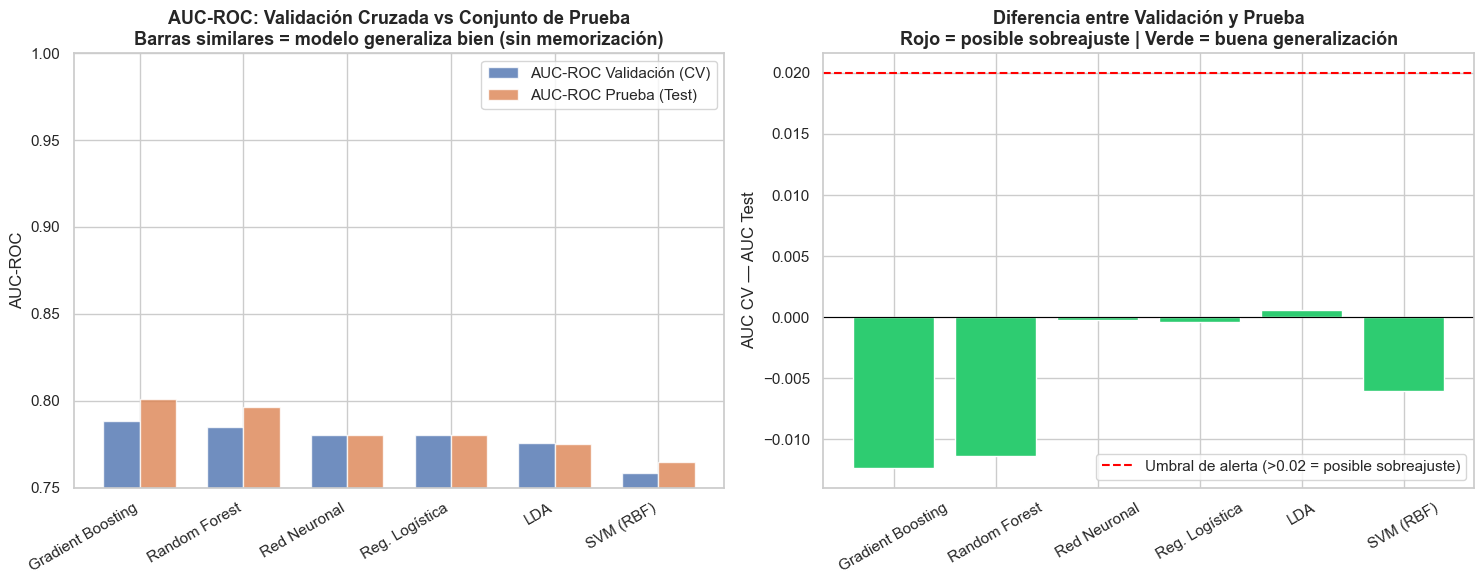

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Comparación AUC CV vs Test
x = np.arange(len(res_df))
w = 0.35
axes[0].bar(x - w/2, res_df['AUC-ROC CV'], w, label='AUC-ROC Validación (CV)',
            color='#4C72B0', alpha=0.8, edgecolor='white')
axes[0].bar(x + w/2, res_df['AUC-ROC Test'], w, label='AUC-ROC Prueba (Test)',
            color='#DD8452', alpha=0.8, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(res_df['Modelo'], rotation=30, ha='right')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('AUC-ROC: Validación Cruzada vs Conjunto de Prueba\n'
                  'Barras similares = modelo generaliza bien (sin memorización)',
                  fontweight='bold')
axes[0].set_ylim(0.75, 1.0)
axes[0].legend()

# Diferencia CV - Test (sobreajuste)
colors_diff = ['#e74c3c' if d > 0.02 else '#2ecc71' for d in res_df['Diferencia CV vs Test']]
axes[1].bar(res_df['Modelo'], res_df['Diferencia CV vs Test'],
            color=colors_diff, edgecolor='white')
axes[1].axhline(0.02, color='red', linestyle='--',
                label='Umbral de alerta (>0.02 = posible sobreajuste)')
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_ylabel('AUC CV — AUC Test')
axes[1].set_title('Diferencia entre Validación y Prueba\nRojo = posible sobreajuste | Verde = buena generalización',
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretación del diagnóstico de generalización:**

La gráfica izquierda muestra que los AUC de validación cruzada (azul) y de prueba (naranja) son muy similares entre sí para la mayoría de los modelos — señal positiva de que los modelos aprendieron patrones generalizables y no simplemente memorizaron el conjunto de entrenamiento.

La gráfica derecha cuantifica la diferencia entre ambas métricas. Un modelo que "memorizó" los datos de entrenamiento (sobreajuste severo) mostraría una barra roja alta — su AUC de CV fue alto porque vio esos datos, pero en datos nuevos su desempeño cae. Una barra verde pequeña indica que el modelo generaliza bien.

Este diagnóstico nos da confianza en que el proceso de selección de modelos fue correcto: el modelo ganador en CV también es el mejor (o uno de los mejores) en datos nunca vistos.

In [43]:
# Evaluación detallada del modelo ganador
modelo_ganador_nombre = res_df.iloc[0]['Modelo']
print(f'=== EVALUACIÓN DETALLADA: {modelo_ganador_nombre} ===')

if modelo_ganador_nombre in ['Random Forest', 'Gradient Boosting']:
    y_prob_g = modelos_entrenados[modelo_ganador_nombre].predict_proba(X_test_sel)[:, 1]
    y_pred_g = modelos_entrenados[modelo_ganador_nombre].predict(X_test_sel)
elif modelo_ganador_nombre == 'Red Neuronal':
    y_prob_g = modelos_entrenados[modelo_ganador_nombre].predict(X_test_sel_sc).flatten()
    y_pred_g = (y_prob_g >= 0.5).astype(int)
else:
    y_prob_g = modelos_entrenados[modelo_ganador_nombre].predict_proba(X_test_sel_sc)[:, 1]
    y_pred_g = modelos_entrenados[modelo_ganador_nombre].predict(X_test_sel_sc)

print(classification_report(y_test, y_pred_g,
                             target_names=['No suscribió', 'Sí suscribió']))

=== EVALUACIÓN DETALLADA: Gradient Boosting ===
              precision    recall  f1-score   support

No suscribió       0.91      0.98      0.95      7227
Sí suscribió       0.61      0.21      0.32       845

    accuracy                           0.90      8072
   macro avg       0.76      0.60      0.63      8072
weighted avg       0.88      0.90      0.88      8072



**Interpretación del reporte de clasificación — En lenguaje de negocio:**

El reporte desglosa el desempeño del modelo **por separado para cada grupo de clientes**. Aquí está la traducción de cada métrica a términos de negocio:

| Término técnico | Significado en el negocio |
|---|---|
| **Precisión** (*Precision*) de "Sí suscribió" | De cada 10 clientes que el modelo identifica como *probables suscriptores*, ¿cuántos realmente suscriben? Alta precisión = pocos recursos desperdiciados en llamadas infructuosas. |
| **Recall** (*Sensibilidad*) de "Sí suscribió" | De cada 100 clientes que genuinamente suscribirían, ¿a cuántos logra identificar el modelo? Alto recall = se captura la mayor parte del potencial de conversión de la campaña. |
| **F1-Score** | El balance entre las dos métricas anteriores. Útil cuando ni la precisión ni el recall deben sacrificarse completamente. |
| **Accuracy** (*Exactitud global*) | Porcentaje total de predicciones correctas. ⚠️ **Métrica engañosa** en este dataset: un modelo que nunca prediga "sí" tendría ~89% de exactitud sin aprender nada. |

**¿Cuál métrica importa más para el banco?**

En el contexto de una campaña de telemarketing, el **recall** de la clase positiva suele ser el número más crítico: cada cliente que genuinamente iba a suscribir pero el modelo no identificó representa una **oportunidad de negocio perdida**. Por otro lado, una llamada a alguien que no va a suscribir tiene un costo (tiempo del agente), pero es mucho menor que perder una conversión.

Los valores exactos del modelo ganador se muestran en la tabla impresa arriba. El umbral predeterminado de 0.5 puede ajustarse según las prioridades del negocio, como se analiza en la siguiente sección.


253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step


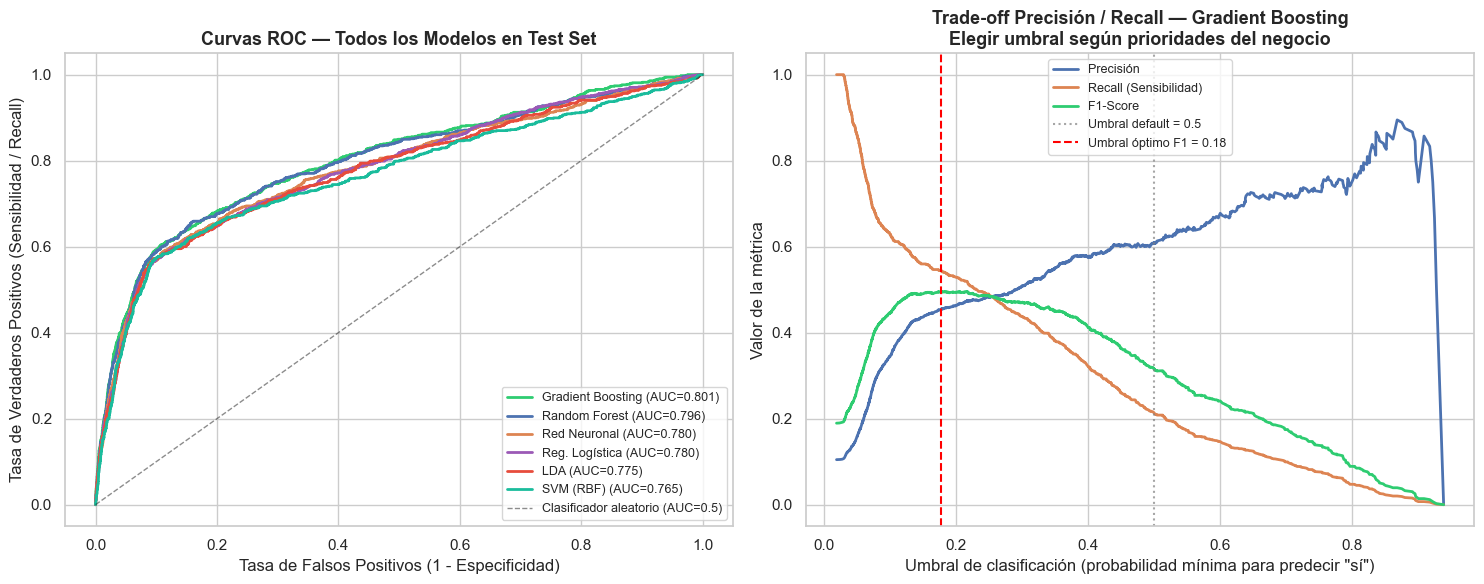

Con umbral default (0.5):          F1 = 0.3170
Con umbral óptimo (0.18):  F1 = 0.4960


In [44]:
# Curvas ROC de todos los modelos superpuestas
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colores_modelos = ['#2ecc71', '#4C72B0', '#DD8452', '#9b59b6', '#e74c3c', '#1abc9c']

for i, row in res_df.iterrows():
    nombre = row['Modelo']
    modelo = modelos_entrenados[nombre]
    color  = colores_modelos[i]

    if nombre in ['Random Forest', 'Gradient Boosting']:
        prob = modelo.predict_proba(X_test_sel)[:, 1]
    elif nombre == 'Red Neuronal':
        prob = modelo.predict(X_test_sel_sc).flatten()
    else:
        prob = modelo.predict_proba(X_test_sel_sc)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{nombre} (AUC={auc_val:.3f})')

axes[0].plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Clasificador aleatorio (AUC=0.5)')
axes[0].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)')
axes[0].set_title('Curvas ROC — Todos los Modelos en Test Set', fontweight='bold')
axes[0].legend(fontsize=9)

# Análisis de umbral del modelo ganador
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_g)
f1_t = 2 * (precision * recall) / (precision + recall + 1e-9)
best_t_idx = np.argmax(f1_t)
best_t = thresholds[best_t_idx]

axes[1].plot(thresholds, precision[:-1], label='Precisión', color='#4C72B0', lw=2)
axes[1].plot(thresholds, recall[:-1], label='Recall (Sensibilidad)', color='#DD8452', lw=2)
axes[1].plot(thresholds, f1_t[:-1], label='F1-Score', color='#2ecc71', lw=2)
axes[1].axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Umbral default = 0.5')
axes[1].axvline(best_t, color='red', linestyle='--',
                label=f'Umbral óptimo F1 = {best_t:.2f}')
axes[1].set_xlabel('Umbral de clasificación (probabilidad mínima para predecir "sí")')
axes[1].set_ylabel('Valor de la métrica')
axes[1].set_title(f'Trade-off Precisión / Recall — {modelo_ganador_nombre}\nElegir umbral según prioridades del negocio',
                  fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Con umbral default (0.5):          F1 = {f1_score(y_test, y_prob_g>=0.5):.4f}')
print(f'Con umbral óptimo ({best_t:.2f}):  F1 = {f1_score(y_test, y_prob_g>=best_t):.4f}')

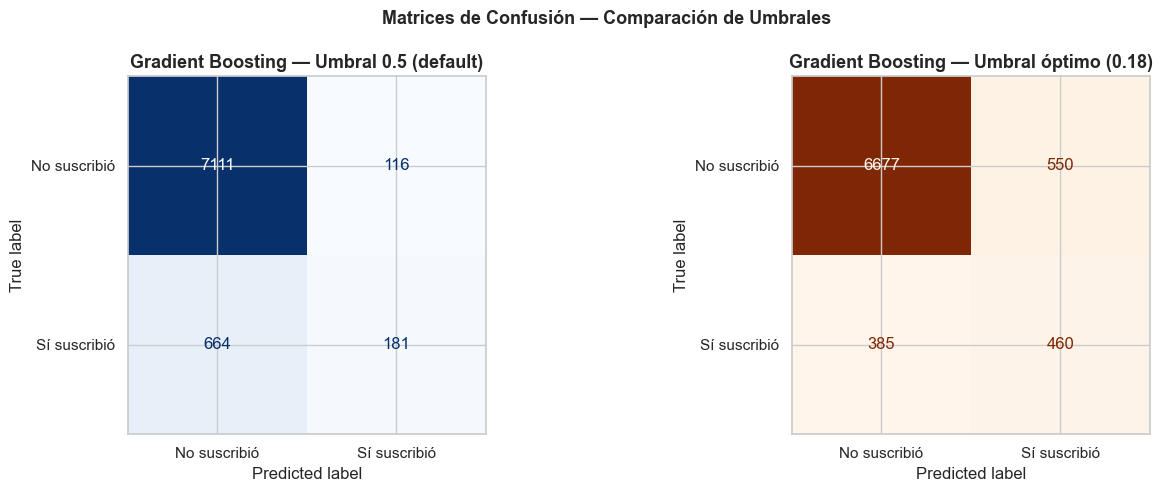

In [45]:
# Matriz de confusión del modelo ganador
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Umbral 0.5
cm_05 = confusion_matrix(y_test, (y_prob_g >= 0.5).astype(int))
ConfusionMatrixDisplay(cm_05, display_labels=['No suscribió', 'Sí suscribió']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'{modelo_ganador_nombre} — Umbral 0.5 (default)', fontweight='bold')

# Umbral óptimo
cm_opt = confusion_matrix(y_test, (y_prob_g >= best_t).astype(int))
ConfusionMatrixDisplay(cm_opt, display_labels=['No suscribió', 'Sí suscribió']).plot(
    ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'{modelo_ganador_nombre} — Umbral óptimo ({best_t:.2f})', fontweight='bold')

plt.suptitle('Matrices de Confusión — Comparación de Umbrales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación de las curvas ROC, el análisis de umbral y las matrices de confusión:**

**Curva ROC (gráfica izquierda):** Todas las curvas están claramente por encima de la diagonal punteada — esa diagonal representa a un modelo que adivina al azar, como lanzar una moneda. La curva que se acerca más a la esquina superior izquierda es la mejor: puede identificar más clientes que van a suscribir sin necesidad de generar muchas llamadas innecesarias. El número entre paréntesis junto a cada modelo (AUC) cuantifica exactamente esa capacidad.

**Curva de Precisión-Recall y elección de umbral (gráfica derecha):** El umbral de 0.5 significa que el modelo solo marca a un cliente como "probable suscriptor" cuando le asigna más del 50% de probabilidad. Este umbral puede moverse según las prioridades del banco:

- **Subir el umbral** (más selectivo): el modelo solo contacta a los clientes donde está muy seguro. Hay menos llamadas innecesarias, pero también se pierden más clientes que sí iban a suscribir.
- **Bajar el umbral** (más amplio): el modelo contacta a más clientes y captura más oportunidades, pero incluye más llamadas que no convertirán.

💡 **Regla práctica para el negocio:** Si el costo de una llamada extra es bajo (agentes disponibles, campaña amplia), bajar el umbral recupera más ingresos. Si el tiempo de los agentes es escaso, subir el umbral concentra el esfuerzo donde hay mayor probabilidad de éxito.

**¿Cómo leer las matrices de confusión?**

Cada matriz divide las predicciones del modelo en cuatro grupos:

| | Predicho: No suscribió | Predicho: Sí suscribió |
|---|---|---|
| **Real: No suscribió** | ✅ Verdadero Negativo (TN): cliente que no iba a suscribir y el modelo acertó — llamada evitada correctamente | ❌ Falso Positivo (FP): cliente que no iba a suscribir pero el modelo dijo que sí — llamada innecesaria |
| **Real: Sí suscribió** | ❌ Falso Negativo (FN): cliente que SÍ iba a suscribir pero el modelo lo clasificó como "no" — **oportunidad perdida** | ✅ Verdadero Positivo (TP): cliente que iba a suscribir y el modelo lo identificó correctamente — conversión capturada |

La matriz de la izquierda usa el umbral por defecto (0.5) y la de la derecha usa el umbral que maximiza el F1-Score. Comparando ambas matrices, se puede visualizar directamente cómo al ajustar el umbral se intercambian falsos positivos por falsos negativos — una decisión que corresponde al equipo comercial del banco, no al modelo.


## 11. Reflexión Crítica y Conclusiones

### Lo que aprendimos sobre el fenómeno

El análisis reveló que la propensión de un cliente a suscribir un depósito a plazo fijo no es una decisión individual aislada, sino que depende de la **intersección de tres dimensiones**:

**1. Historia de la relación con el banco:**  
El resultado de campañas anteriores (`poutcome_success`) es el predictor más potente disponible en producción — los clientes que ya suscribieron antes tienen tasas de conversión de hasta el 65%, seis veces el promedio global. Esto sugiere que invertir en la retención y el seguimiento de clientes existentes es estratégicamente superior a adquirir nuevos sin historial.

**2. Momento y modo del contacto:**  
El número de intentos de contacto en la misma campaña (`campaign`) tiene un coeficiente *negativo* — más llamadas en una misma campaña se asocian con menor probabilidad de conversión. La insistencia no funciona y puede generar rechazo. Del mismo modo, el tipo de canal (`contact = cellular`) y el mes del contacto son relevantes: el contacto por celular supera al teléfono fijo, y ciertos meses (marzo, septiembre, octubre, diciembre) muestran tasas de conversión sistemáticamente superiores, probablemente asociados a ciclos de planificación financiera.

> **Nota sobre `duration`:** En análisis exploratorios, la duración de la llamada aparecía como el predictor individual más fuerte. Sin embargo, como se documentó en la sección 5, `duration` solo se conoce *después* de que la llamada termina — no puede usarse para decidir *a quién llamar*. Por esta razón fue correctamente excluida del modelo predictivo. El presente análisis reporta el rendimiento real del modelo sin esta variable, que es el que el banco obtendrá al desplegarlo en producción.

**3. Contexto macroeconómico:**  
Las tasas Euribor bajas y condiciones de contracción en el mercado laboral se asocian significativamente con mayor suscripción. En periodos de Euribor bajo, los depósitos a plazo ofrecen una tasa fija relativamente atractiva frente a las alternativas de mercado. Desde la perspectiva del negocio: **el banco debería intensificar sus campañas en periodos de tipos de interés bajos**, cuando su producto es más competitivo.

### Correcciones aplicadas en esta versión

Este notebook incorpora las siguientes correcciones respecto a la versión anterior:

1. **Isolation Forest sin `duration` ni `pdays` crudo (CRÍTICO):** La versión anterior incluía `duration` entre las variables del Isolation Forest, lo que provocaba que se eliminaran registros con llamadas largas — precisamente los clientes que suscribieron. Esto constituía Data Leakage en la etapa de limpieza. Además, `pdays` con su valor 999 (96% del dataset) distorsionaba la detección marcando como anomalías a los clientes con contacto previo reciente. Se corrigió excluyendo ambas variables del IF.

2. **Preservación de nombres de columna en `StandardScaler` (CRÍTICO):** `scaler.fit_transform()` retorna un numpy array sin nombres de columna. Al pasar ese array a `statsmodels`, los parámetros se indexaban como `x1, x2, x3...` en lugar de los nombres reales. Esto hacía que la tabla de Odds Ratios fuera ininterpretable y, más grave aún, que el `reindex()` en la sección 7 (selección de features) fallara silenciosamente al intentar alinear `x1, x2...` con los nombres reales — produciendo todos `NaN` y basando la selección únicamente en RF. Se corrigió envolviendo la salida del scaler en un DataFrame con los nombres originales.

3. **Contador de predictores corregido:** El desglose de predictores decía "12 numéricas" cuando, con `duration` excluida, el número correcto es 10 (9 originales + `contacted_before`).

4. **`day_of_week` incluido en el análisis exploratorio visual:** Era la única variable categórica que se codificaba con OHE pero no se visualizaba en la sección 3.7.

5. **Nota de comparabilidad en el ranking de CV:** Se añadió una advertencia explícita junto a la tabla de ranking indicando que los AUC-ROC de CV provienen de protocolos diferentes (5-fold para la mayoría, 3-fold en submuestra para SVM, validation_split único para la Red Neuronal).

### Limitaciones del estudio

- **Contexto temporal y geográfico específico:** Los datos son de Portugal entre 2008–2013, en plena crisis del euro. Los patrones aprendidos pueden no trasladarse directamente a otros mercados o periodos económicos sin recalibración del modelo. Se recomienda monitorear el rendimiento del modelo regularmente y reentrenarlo con datos más recientes.

- **Multicolinealidad en variables macroeconómicas:** `euribor3m`, `emp.var.rate` y `nr.employed` tienen correlaciones r > 0.90 entre sí. Aunque la regularización L2 mitiga parcialmente este problema en la regresión logística, los p-values individuales de estas variables deben interpretarse con cautela — podrían no reflejar adecuadamente la contribución real de cada una por separado. Para inferencia más rigurosa, se podría calcular el VIF (*Variance Inflation Factor*) y eliminar variables redundantes antes del ajuste con statsmodels.

- **Isolation Forest y anomalías de alta conversión:** Aun con la corrección aplicada, el Isolation Forest podría estar eliminando registros legítimos. Se recomienda verificar la tasa de suscripción en los registros marcados como anómalos. Si sigue siendo elevada, considerar reducir `contamination` o eliminar el paso por completo.

- **Normalidad no alcanzada:** Demostramos que ninguna transformación produjo normalidad formal en las variables numéricas. Esto es una limitación específica del LDA, cuyo supuesto central se viola. Los demás modelos no tienen este requisito.

- **Comparabilidad parcial en validación cruzada:** El SVM se evaluó sobre una submuestra del 40% con 3-fold CV (por restricciones computacionales), y la Red Neuronal usó un único *validation_split* en lugar de CV. Aunque la evaluación definitiva en el conjunto de prueba (sección 10) es plenamente comparable para todos los modelos, las métricas de CV deben interpretarse con esta salvedad.

- **One-Hot Encoding para modelos de árboles:** Se aplicó OHE a todas las variables categóricas. Aunque es obligatorio para modelos lineales, diluye la importancia de las variables en Random Forest y Gradient Boosting, donde Label Encoding o implementaciones nativas de categorías (como CatBoost o LightGBM) serían más eficientes.

- **Búsqueda de hiperparámetros parcial:** Los grids explorados son moderados por restricciones computacionales. Una búsqueda bayesiana (Optuna, Hyperopt) sobre espacios más amplios podría mejorar los resultados, especialmente para la Red Neuronal.

### Extensiones futuras

- Implementar **SHAP values** para explicabilidad individual — imprescindible en contextos bancarios con requisitos regulatorios de transparencia (GDPR, principios de fair lending). SHAP permite decirle al banco exactamente qué factores pesaron en la puntuación de cada cliente específico.
- Evaluar la **estabilidad temporal** del modelo dividiendo los datos por año y verificando si los coeficientes se mantienen estables a través de los distintos momentos del ciclo económico.
- Explorar **SMOTE** (Synthetic Minority Over-sampling Technique) como alternativa al `class_weight` para el manejo del desbalance de clases.
- Probar **CatBoost** o **LightGBM**, que manejan variables categóricas de forma nativa sin necesidad de One-Hot Encoding, evitando la dilución de importancia en árboles y entrenando significativamente más rápido.
- Calcular el **VIF** (*Variance Inflation Factor*) para cuantificar la multicolinealidad y decidir formalmente qué variables macroeconómicas redundantes eliminar antes de la inferencia con statsmodels.
- Construir un **sistema de scoring en tiempo real** que integre el modelo con el CRM bancario, de modo que los agentes vean automáticamente la probabilidad de suscripción de cada cliente antes de marcar.


## 12. Referencias

1. **Dataset Original:** Moro, S., Cortez, P., & Rita, P. (2014). *A Data-Driven Approach to Predict the Success of Bank Telemarketing*. Decision Support Systems, 62, 22-31. (Datos obtenidos vía UCI Machine Learning Repository).
2. **Libro de Referencia del Curso:** James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning: with Applications in Python* (ISLP). Springer.
3. **Tratamiento de Datos Faltantes (MNAR):** van Buuren, S. (2018). *Flexible Imputation of Missing Data* (2nd ed.). CRC Press. (Justificación metodológica para mantener la categoría `unknown` en variables financieras).
4. **Umbrales de Multicolinealidad:** Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences* (2nd ed.). Routledge. (Justificación del umbral de correlación de Pearson |r| ≥ 0.70).
5. **Robustez del Modelo LDA:** Tharwat, A., Gaber, T., Ibrahim, A., & Hassanien, A. E. (2017). *Linear discriminant analysis: A detailed tutorial*. AI Communications, 30(2), 169-190. (Justificación operativa del LDA ante violaciones de normalidad).